# Decision Tree Lab

In [2]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import arff
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score 

## 1 Debug and Eval

### 1.1 (5%) Debug 

- Train a DecisionTreeClassifier on the [Iris Dataset](https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/iris.arff) using all default parameters.
- If using Dataframes you may want to change the class values from bytecodes to strings with
iris_df['class'] = iris_df['class'].str.decode('utf-8') 

Expected Accuracy = [1.0]


In [3]:
# Debug
# Learn the data
train_data, train_meta = arff.loadarff("data/iris.arff")
iris_df= pd.DataFrame(train_data)

# Decode "class" from bytecodes to strings!
iris_df["class"] = iris_df["class"].str.decode("utf-8")

# Quick EDA
print("EDA:")
print("\tFirst 5 rows of iris data set: ")
display(iris_df.head())

print("\n\tIris Class Distribution:")
display(iris_df["class"])

# Split into X and y
X = iris_df.drop(["class"], axis = 1)
y = iris_df["class"]

# Get data splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Initialize, fit Decision Tree with default parameters
dtc = DecisionTreeClassifier()
dtc.fit(X_train, np.ravel(y_train))

# Predictions!
y_train_pred = dtc.predict(X_train)
y_test_pred = dtc.predict(X_test)

# Accuracy!
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Train Accuracy:")
print(f"\t{train_accuracy}")
print("Test Accuracy: ")
print(f"\t{test_accuracy}")


EDA:
	First 5 rows of iris data set: 


,sepallength,sepalwidth,petallength,petalwidth,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa



	Iris Class Distribution:


0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
            ...      
145    Iris-virginica
146    Iris-virginica
147    Iris-virginica
148    Iris-virginica
149    Iris-virginica
Name: class, Length: 150, dtype: str

Train Accuracy:
	1.0
Test Accuracy: 
	1.0


### 1.2 (5%) Evaluation 

- Train on the iris data set again but this time with max_depth = 3 and output the accuracy

In [4]:
# Evaluation
# Initialize, fit Decision Tree with max_depth = 3
dtc2 = DecisionTreeClassifier(max_depth = 3)
dtc2.fit(X_train, np.ravel(y_train))

# Predictions!
y_train_pred = dtc2.predict(X_train)
y_test_pred = dtc2.predict(X_test)

# Accuracy!
train_accuracy2 = accuracy_score(y_train, y_train_pred)
test_accuracy2 = accuracy_score(y_test, y_test_pred)

print("Accuracies of Decision Tree Classifier with max_depth = 3:")
print("\tTrain Accuracy:")
print(f"\t\t{train_accuracy2}")
print("\tTest Accuracy: ")
print(f"\t\t{test_accuracy2}")

Accuracies of Decision Tree Classifier with max_depth = 3:
	Train Accuracy:
		0.9583333333333334
	Test Accuracy: 
		1.0


#### Discussion
What did you see? What were the differences in accuracy between the two trained models? How do you account for the differences or no differences? 

In this short portion, I did the typical EDA, followed by an 80/20 train/test split with a random state set so that it could be reproduced. I then calculated both the test and train accuracies with .score() for both of the classifiers. 

The Decision Tree Classifier with default parameters had both a train and test accuracy of 1.0. This tells me that with the silghtly more complex decision tree, it was able to learn/memorize the train data perfectly and the resulting decision boundary was true and able to predict all classes with 100% accuracy.

The Decision Tree Classifier with max_depth = 3, i.e., the slightly simpler model, had a slightly less accurate training score (0.95833), meaning with less splits it wasn't able to perfectly capture all of the training data. But, since the test accuracy remained at 1.0, it is safe to say that even with the slightly simpler model, the true decision boundry was able to be captured and correctly predict all instances in the test data set. 

## 2. Missing Values, N-fold CV, and Decision Tree Items  

### 2.1 (15%) Handling missing values
- Use this [Voting Dataset with missing values](https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/voting_with_missing.arff)
- This data set has missing data.  Create an extra feature value for each feature with missing data. For example, if the feature were color with possible values R, G, B, you would add a fourth value (e.g. U or ? for unknown).
- Do not use a stopping criteria. Induce the tree as far as it can go (until classes are pure or there are no more data or attributes to split on).
- SKlearn does not allow nominal features, which initially seems odd. However, SKlearn uses the binary CART algorithm where a nominal data value like color is broken down into blue or not blue, red or not red, etc.  It is thus natural to just use one-hot encoding for each nominal feature.
- Use an 80/20 train/test split.
- Report the training and test set accuracies.

EDA:
	First 5 rows of voting data set: 


,handicapped-infants,water-project-cost-sharing,adoption-of-the-budget-resolution,physician-fee-freeze,el-salvador-aid,religious-groups-in-schools,anti-satellite-test-ban,aid-to-nicaraguan-contras,mx-missile,immigration,synfuels-corporation-cutback,education-spending,superfund-right-to-sue,crime,duty-free-exports,export-administration-act-south-africa,Class
0,b'n',b'y',b'n',b'y',b'y',b'y',b'n',b'n',b'n',b'y',b'?',b'y',b'y',b'y',b'n',b'y',b'republican'
1,b'n',b'y',b'n',b'y',b'y',b'y',b'n',b'n',b'n',b'n',b'n',b'y',b'y',b'y',b'n',b'?',b'republican'
2,b'?',b'y',b'y',b'?',b'y',b'y',b'n',b'n',b'n',b'n',b'y',b'n',b'y',b'y',b'n',b'n',b'democrat'
3,b'n',b'y',b'y',b'n',b'?',b'y',b'n',b'n',b'n',b'n',b'y',b'n',b'y',b'n',b'n',b'y',b'democrat'
4,b'y',b'y',b'y',b'n',b'y',b'y',b'n',b'n',b'n',b'n',b'y',b'?',b'y',b'y',b'y',b'y',b'democrat'



	Voting Class Distribution:


0      b'republican'
1      b'republican'
2        b'democrat'
3        b'democrat'
4        b'democrat'
           ...      
430    b'republican'
431      b'democrat'
432    b'republican'
433    b'republican'
434    b'republican'
Name: Class, Length: 435, dtype: object

The "Class" column is encoded. Decoding!

Data (without identifying missing values): 


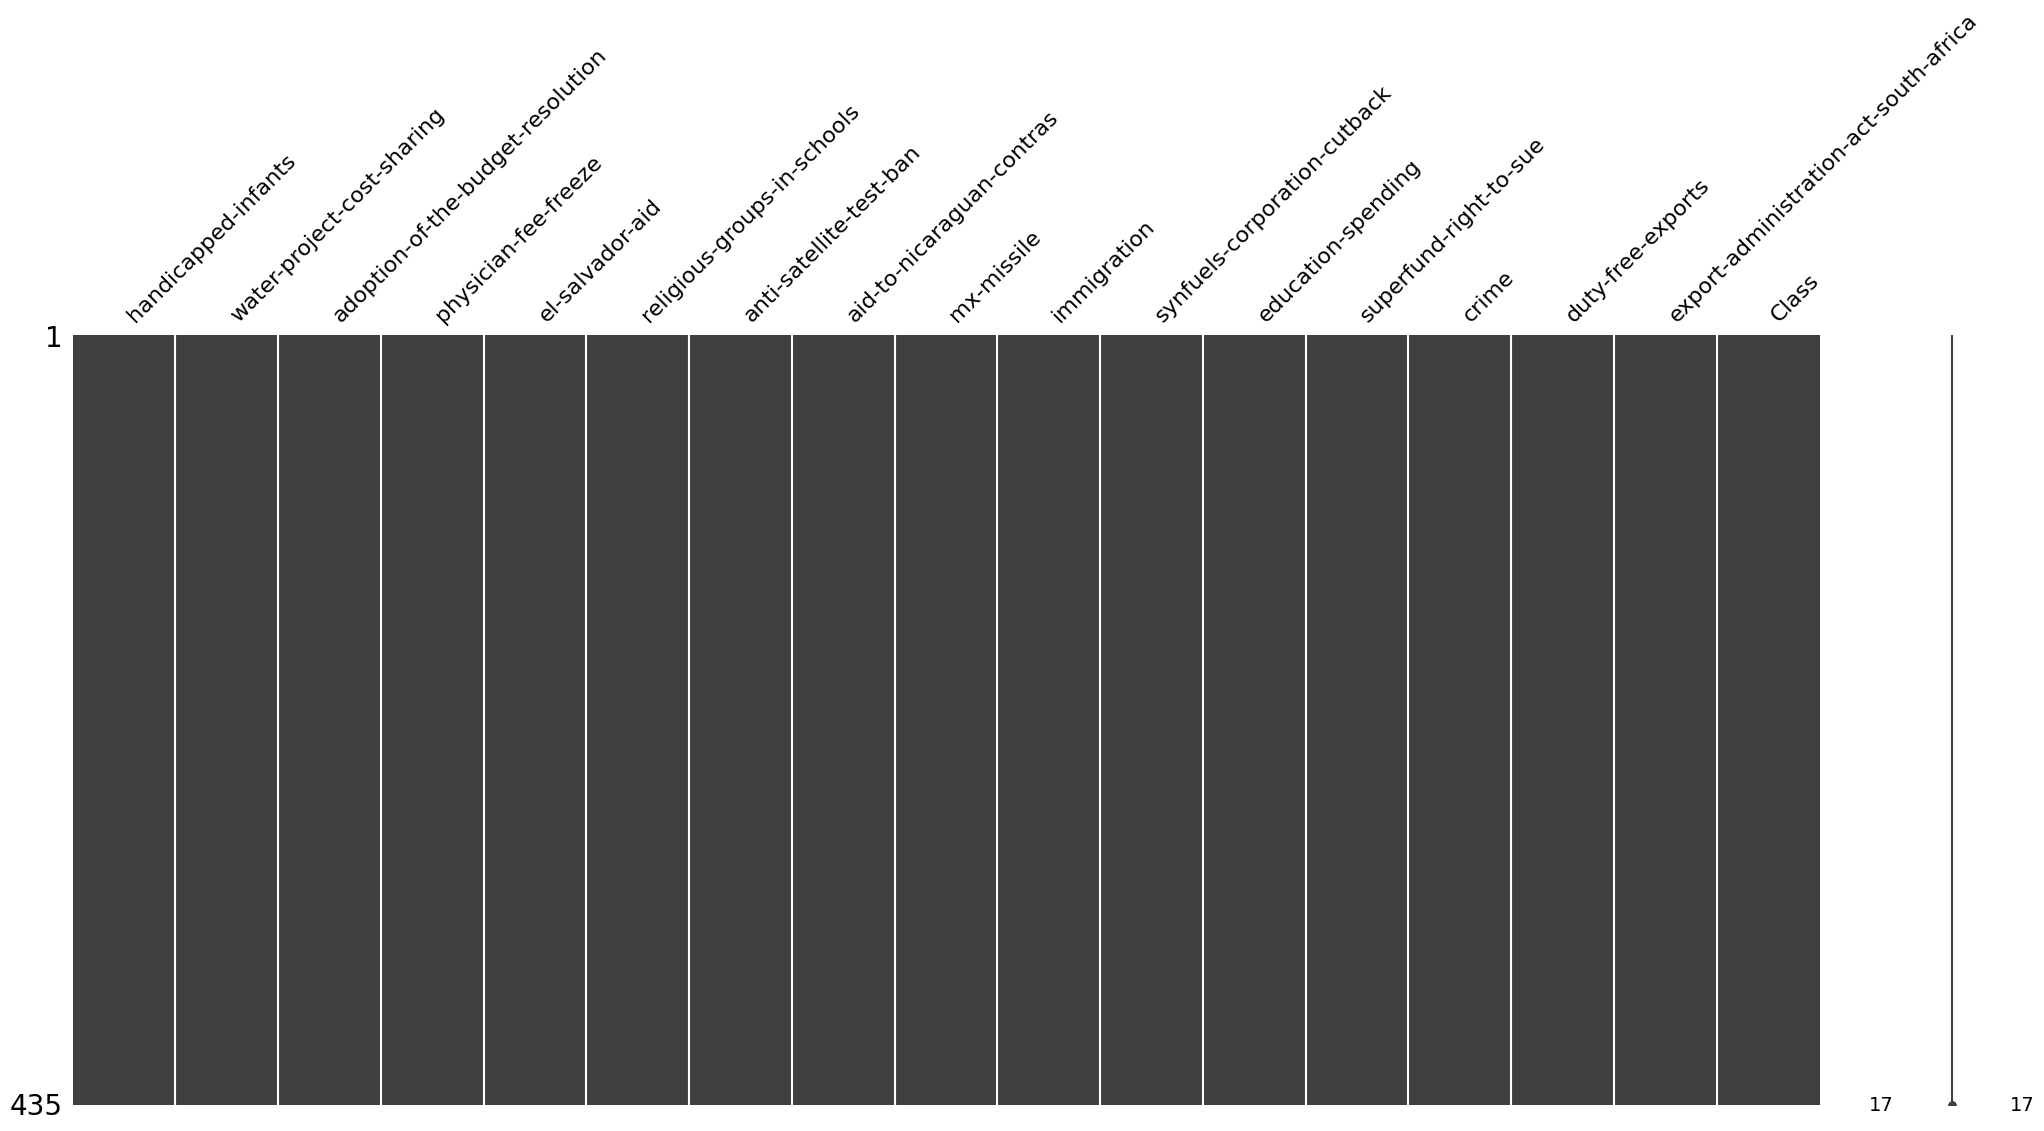

Data (with identified missing values): 


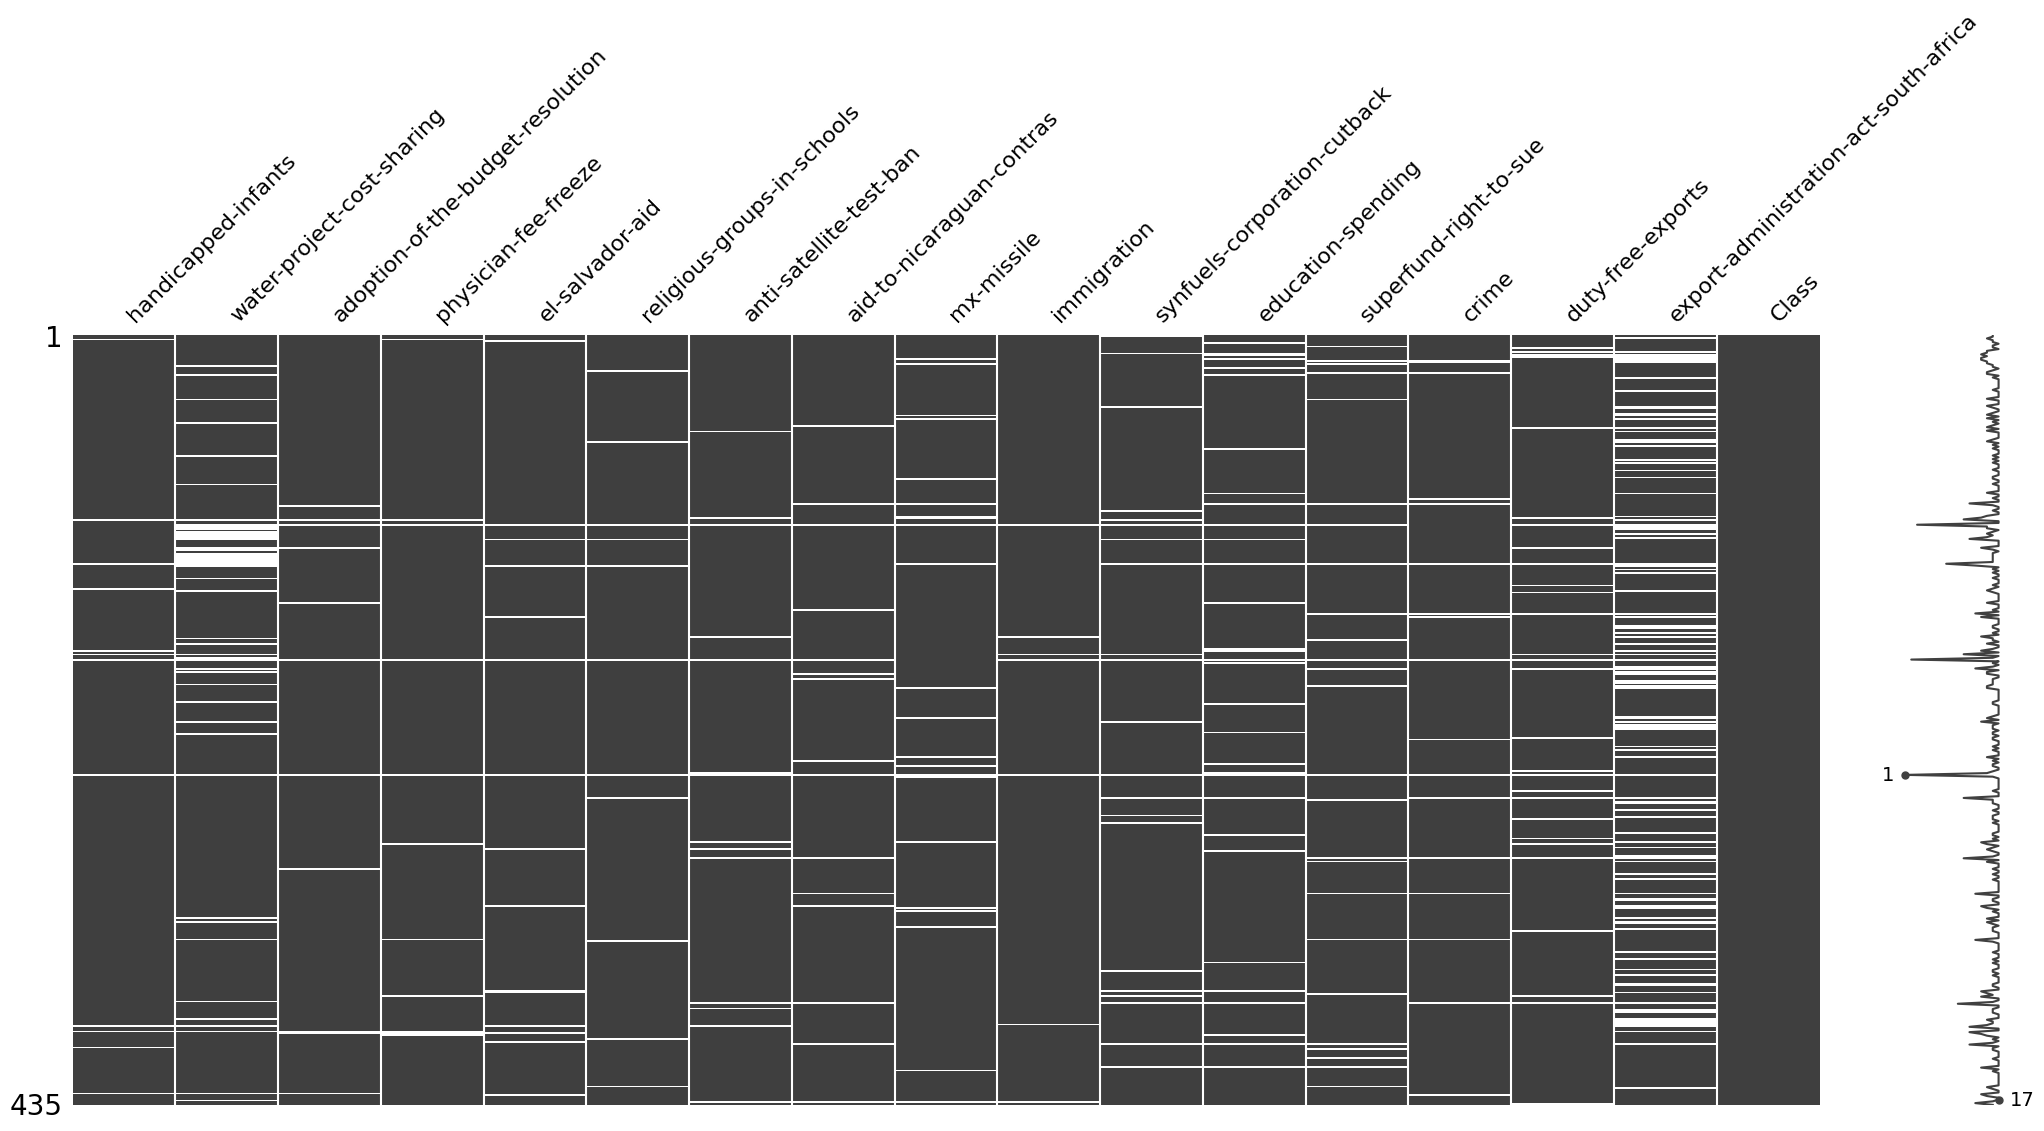

Accuracies of Decision Tree Classifier with default parameters:
	Train Accuracy:
		1.0
	Test Accuracy: 
		0.9540229885057471


In [ ]:
import missingno as msno

# Learn data with missing values
train_data, train_meta = arff.loadarff("data/voting_with_missing.arff")
voting_df = pd.DataFrame(train_data)

# Quick EDA 
print("EDA:")
print("\tFirst 5 rows of voting data set: ")
display(voting_df.head())

print("\n\tVoting Class Distribution:")
display(voting_df["Class"])
print("The \"Class\" column is encoded. Decoding!")

print("\nData (without identifying missing values): ")
msno.matrix(voting_df)
plt.show()

print("Data (with identified missing values): ")
voting_na_df = voting_df.replace(b'?', np.nan)
msno.matrix(voting_na_df)
plt.show()

# Decode
voting_na_df["Class"] = voting_na_df["Class"].str.decode("utf-8")

# Get X and y
X = voting_na_df.drop(["Class"], axis = 1)
y = voting_na_df["Class"]

# Fill NA values with a new feature value to enable a split on these values:
X = X.fillna("Unknown") 

# One-hot encoding for nominal features:
X = pd.get_dummies(X)

# Create a split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42)

# Model initialize and fit
dtc_voting = DecisionTreeClassifier()
dtc_voting.fit(X_train, np.ravel(y_train))

# Predictions!
y_train_pred = dtc_voting.predict(X_train)
y_test_pred = dtc_voting.predict(X_test)

# Accuracy Scores!
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Accuracies of Decision Tree Classifier with default parameters:")
print("\tTrain Accuracy:")
print(f"\t\t{train_accuracy}")
print("\tTest Accuracy: ")
print(f"\t\t{test_accuracy}")


#### Discussion
Report on your accuracies and include explaining how the missing values were handled by your model

Here, I followed a very similar process for doing EDA and setting everything up, just with a few added things to show the missing information and to do the handling of the data. 

The general workflow of my program is:
    A brief EDA to show the structure of the data frame, what the dimensions are and what the "Class' attribute looks like, as well as a comment about how class values will need to be decoded to proceed effectively. Lastly, including images of the data to show the missing values that are present in the used data set. Then, following the EDA, I decoded "Class", got my X and y data frames set up (including filling na values and getting dummies which will be explained in the next section), split the data, intiated and fit my Decision Tree Classifier, and then calculated (and printed) my accuracy scores. Overall, A pretty straight forward process. 

In terms of how the actual missing values were handled by my model:
    I first showed the table with the missing values not identified, mostly for myself so I could envision what what going on here, and then used .replace() to replace the byte encoded question marks with nan values like we were showed in class. Later in my code, I used .fillna() to change the nan values that I formerly replaced the question marks with to change all of those values to the value "Unknown." I did this so that when I went to one-hot encode - which is just a way of converting nominal values into numbers (in this case creating binary columns, 0 and 1)- that "Unknown" would be treated as a real, additional feature value / category, and could be used in the decision tree splits. If these were left as nan values, get_dummies() or splitting this data set would ignore the values, and they would have no influence on these splits. I then used get_dummies() which does the actual converting of nominal values into columns that can have a 1 or 0 value. From there, I did everything like normal!

Accuracy Scores:
    The training accuracy of this model is a 1.0, which is to be expected! It seems like decision trees, especially when there is no defined stopping point, will continue to make decisions until all training data points are classified correctly. Using these decision nodes that are determined through the training data can predict the test data with about a 94% accuracy after all of the fancy one-hot encoding and decoding and everything else that we did to the data. Which I would say is very good and accuracte! 

### 2.2 (15%)  N-fold Cross Validation
- Learn the [Cars Dataset](https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/cars.arff) with the decision tree.
- Create a table with the 10-fold cross validation accuracies and show the average predicted accuracy.
- Try it again with 5-fold CV and create and show that table also.

In [6]:
from sklearn.model_selection import cross_val_score

# Learn the data, make a data frame
train_data, meta_data = arff.loadarff("data/cars.arff")
cars_df = pd.DataFrame(train_data)

# Quick EDA
print("EDA: ")
print("\tFirst 5 rows of cars data set:")
display(cars_df.head())

print("\nCar Type Distributions: ")
display(cars_df["class"].value_counts().sort_index())

print(f"Data shape: {cars_df}")

# Decode all columns, one-hot encode X
print("\nThe data is in bytes! Decoding now...\n")
for col in cars_df.columns:
    cars_df[col] = cars_df[col].str.decode("utf-8")

    # Create X and y frames
X = cars_df.drop(["class"], axis = 1)
y = cars_df["class"]

X = pd.get_dummies(X)

# Do a 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 11
)

# Initialize and fit the model
dtc_cars = DecisionTreeClassifier()
dtc_cars.fit(X_train, np.ravel(y_train))

print("Cross Validation Accuracies for a 10-fold Cross Validation:")
# Calculate the 10-fold cross validation accuracies
ten_fold_cv = cross_val_score(
    dtc_cars, X, y, cv = 10, scoring = "accuracy"
)
# Calculate average
avg_ten_fold = np.mean(ten_fold_cv)
# Create and display table
ten_fold_table= pd.DataFrame({"Fold": range(1,11), "Accuracy": ten_fold_cv})
ten_fold_table.loc["Average"] = ["Average", avg_ten_fold]
ten_fold_table.set_index("Fold", inplace = True)
display(ten_fold_table)

print("\nCross Validation Accuracies for a 5-fold Cross Validation:")
# Calculate the 5-fold cross validatoin accuracies 
five_fold_cv = cross_val_score(
    dtc_cars, X, y, cv = 5, scoring = "accuracy"
)
# Calculate average
avg_five_fold = np.mean(five_fold_cv)
# Create and display table
five_fold_table = pd.DataFrame({"Fold": range(1,6), "Accuracy": five_fold_cv})
five_fold_table.loc["Average"] = ["Average", avg_five_fold]
five_fold_table.set_index("Fold", inplace = True)
display(five_fold_table)

EDA: 
	First 5 rows of cars data set:


,buying,maint,doors,persons,lug_boot,safety,class
0,b'vhigh',b'vhigh',b'2',b'2',b'small',b'low',b'unacc'
1,b'vhigh',b'vhigh',b'2',b'2',b'small',b'med',b'unacc'
2,b'vhigh',b'vhigh',b'2',b'2',b'small',b'high',b'unacc'
3,b'vhigh',b'vhigh',b'2',b'2',b'med',b'low',b'unacc'
4,b'vhigh',b'vhigh',b'2',b'2',b'med',b'med',b'unacc'



Car Type Distributions: 


class
b'acc'       384
b'good'       69
b'unacc'    1210
b'vgood'      65
Name: count, dtype: int64

Data shape:         buying     maint     doors  persons  lug_boot   safety     class
0     b'vhigh'  b'vhigh'      b'2'     b'2'  b'small'   b'low'  b'unacc'
1     b'vhigh'  b'vhigh'      b'2'     b'2'  b'small'   b'med'  b'unacc'
2     b'vhigh'  b'vhigh'      b'2'     b'2'  b'small'  b'high'  b'unacc'
3     b'vhigh'  b'vhigh'      b'2'     b'2'    b'med'   b'low'  b'unacc'
4     b'vhigh'  b'vhigh'      b'2'     b'2'    b'med'   b'med'  b'unacc'
...        ...       ...       ...      ...       ...      ...       ...
1723    b'low'    b'low'  b'5more'  b'more'    b'med'   b'med'   b'good'
1724    b'low'    b'low'  b'5more'  b'more'    b'med'  b'high'  b'vgood'
1725    b'low'    b'low'  b'5more'  b'more'    b'big'   b'low'  b'unacc'
1726    b'low'    b'low'  b'5more'  b'more'    b'big'   b'med'   b'good'
1727    b'low'    b'low'  b'5more'  b'more'    b'big'  b'high'  b'vgood'

[1728 rows x 7 columns]

The data is in bytes! Decoding now...

Cross Validation Accuracies for a 10-fold Cross

,Accuracy
Fold,
1,0.757225
2,0.786127
3,0.924855
4,0.676301
5,0.861272
6,0.913295
7,0.895954
8,0.861272
9,0.912791



Cross Validation Accuracies for a 5-fold Cross Validation:


,Accuracy
Fold,
1,0.731214
2,0.708092
3,0.745665
4,0.753623
5,0.805797
Average,0.748878


#### Discussion
Explain n-fold cross validation. Why do we do it? How is it useful? What does it reveal? Do we end up with a model? If so, which one? 

N-fold cross validation is a model evaluation technique where the data set is split into n equal sized parts, also called folds! The data will be trained on groups that consist of all folds but one, using the remaining fold as a kind of check or validation set. This process is repeated for every group of folds, and accuracy scores are calculated for all of them. These scores can be averages (like we did here) to see how the model performs over different splits, using different sections to test.

Often, a given train/test split can actually result in very different results just on a random split, some splits are "lucky" or result in better classification or accuracy scores. By trying numerous different splits (using the folds that were described in the above step), and also ensuring that every point is used in both testing (once) and training (n - 1 times) allows for much more consistency and more accuractely reported scoring metrics. I kind of think of it as reducing the dependency of the model on any one given train / test split, almost like collecting more samples in a statistical study, which makes the data more informative and more accurate. It is useful (and we do it because) it allows for more reliable metrics!

It can reveal how stable the model is, which includes things like overfitting. If the scores across each fold are really greatly different from one another, then it is a good indication that the model is super suceptable to change with slightly different splits or that the model could be way overfitted for certain splits. On the other hand, if you see incredibly consistent accuracy scores for each of the folds, it could be a good indication that the model is more stable / balanced. In the ten-fold cross validation that we performed we saw values as low as 0.67 and as high as 0.92, which is a huge range, which we also see some of in the 5-fold cross validation, potentially indicating that it isn't a great model.

Cross validation, and the process of calculating all of these scores, does not give us a trained model in of itself. The purpose of cross-validation is to see how accuracies change, allowing us to see the stability of an individual model. Hyperparameters can be tuned by calculating cross validation scores for each one of our trained models in an attempt to find the hyperparameters that result in the best accuracies/metrics, allowing us to use this information to create/train the final, tuned, and cross validated classifier model.

### 2.3 (10%) Decision Tree Intuition
For each of the two problems above (Voting and Cars):
- Print the full tree for each.  You may use tree.plot_tree(clf) or [another way](https://mljar.com/blog/visualize-decision-tree/) if you prefer.  tree.plot_tree has a number of parameters which you can try which let you print more informative trees which can help your discussion.
- Train both again with max_depth = 2 and print these smaller trees and include them in your report.
- Summarize in English what these 2 smaller decision trees have learned (i.e. look at the induced trees and describe what "rules" they discovered). 
- Compare your thoughts on important features with the attribute feature_importances_

Printing full trees for "voting.arff" and "cars.arff":


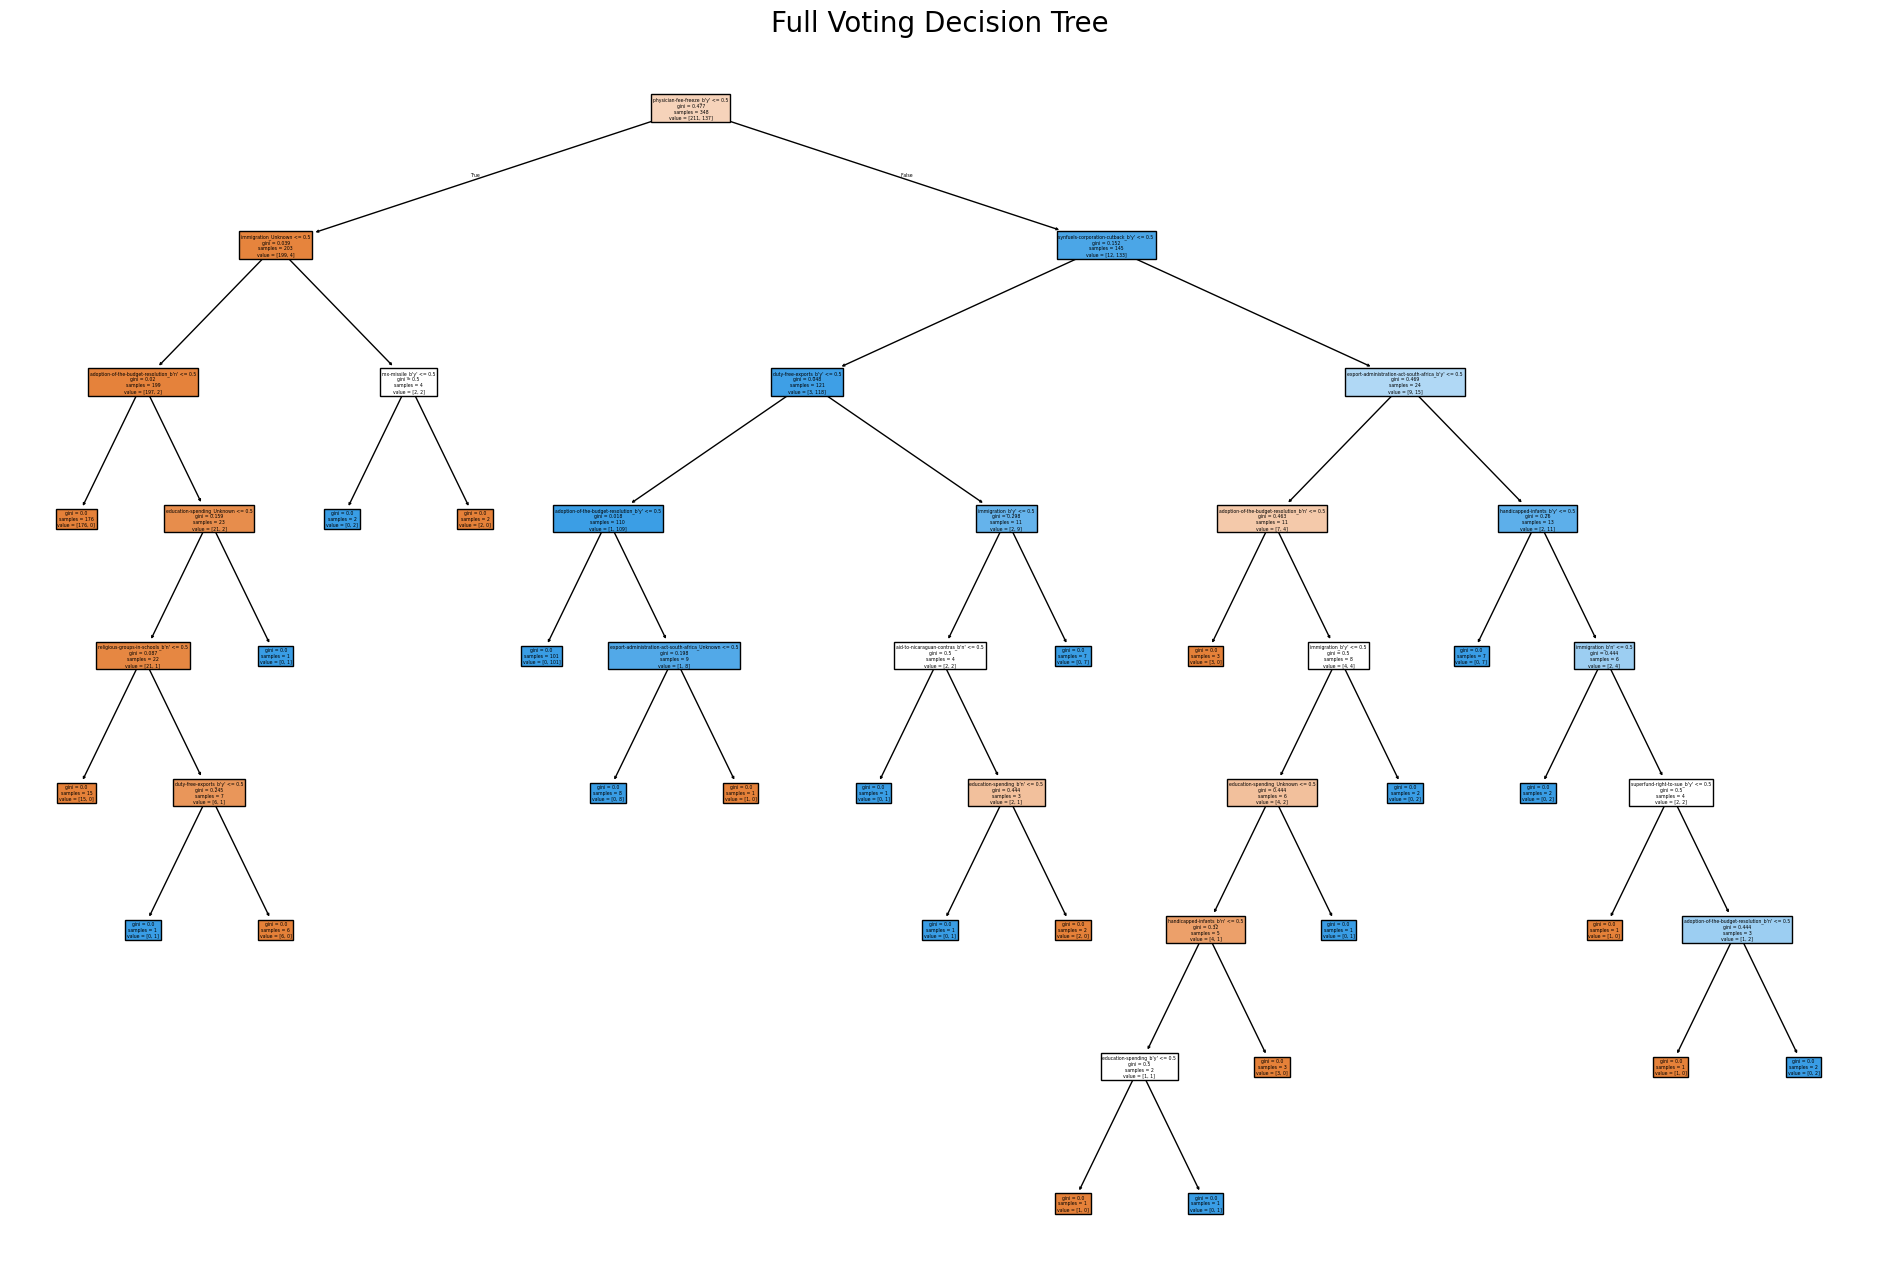

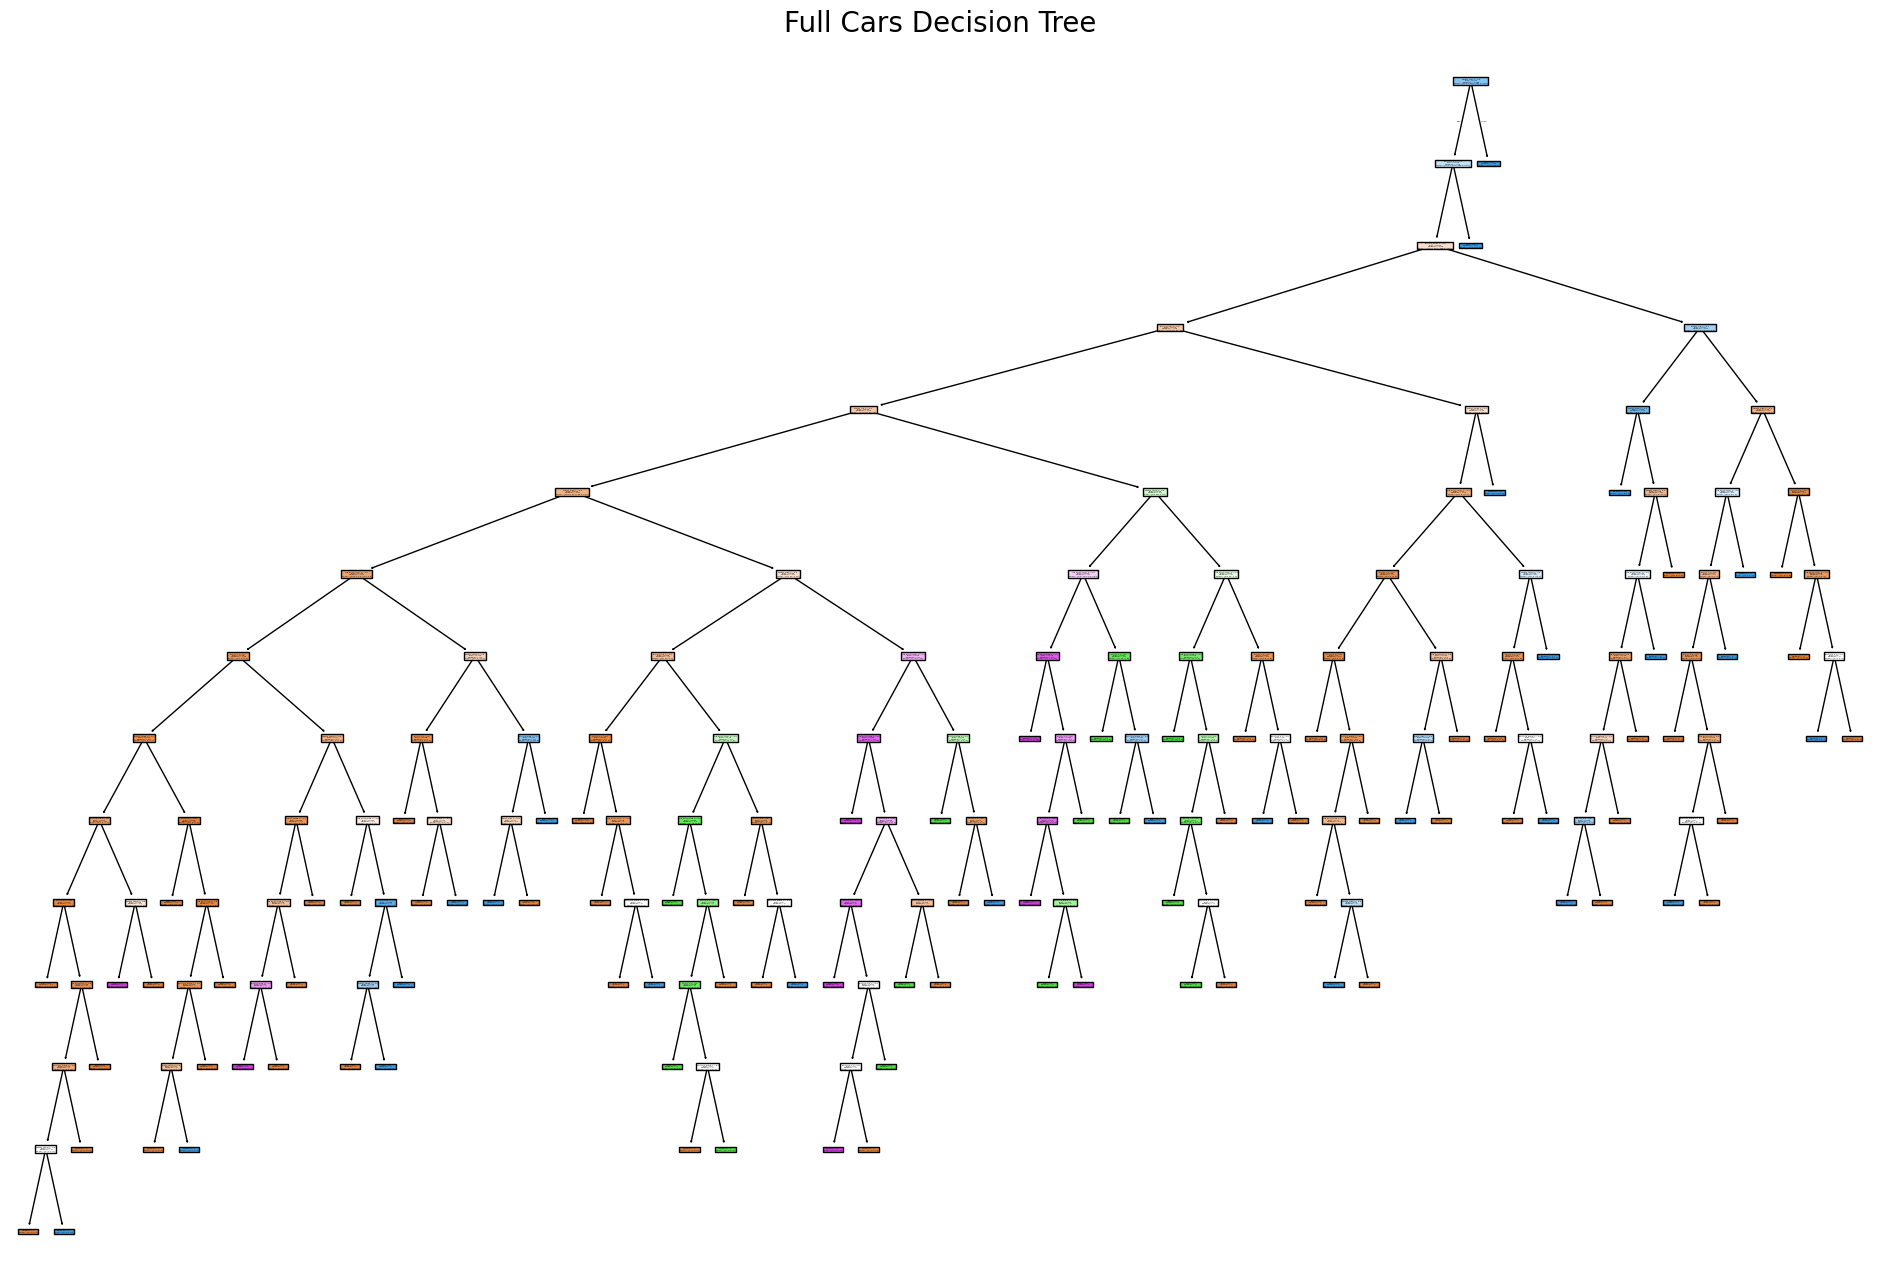

Printing small (max_depth = 2) trees for "voting.arff" and "cars.arff":


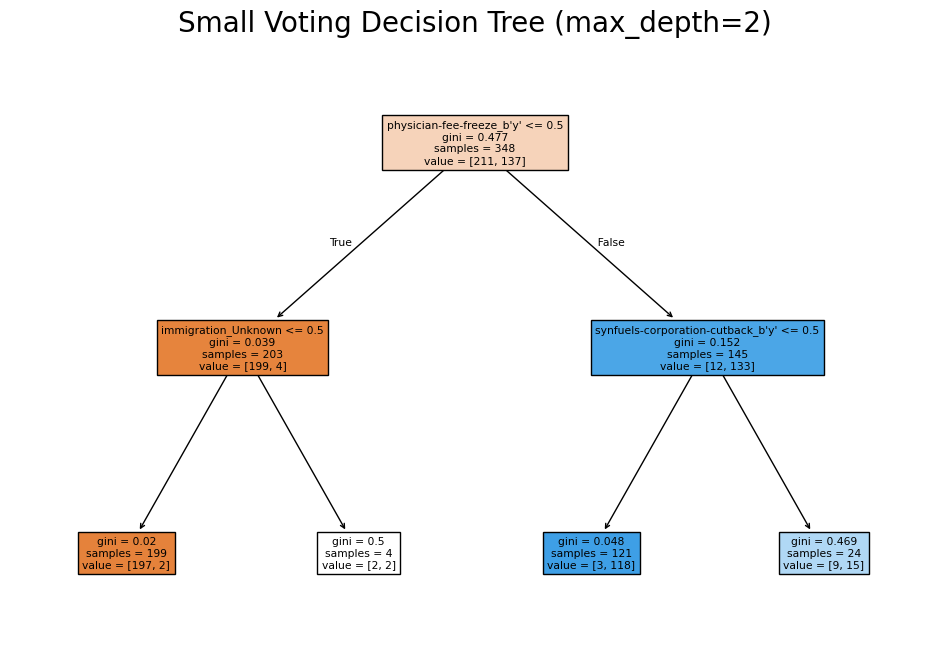

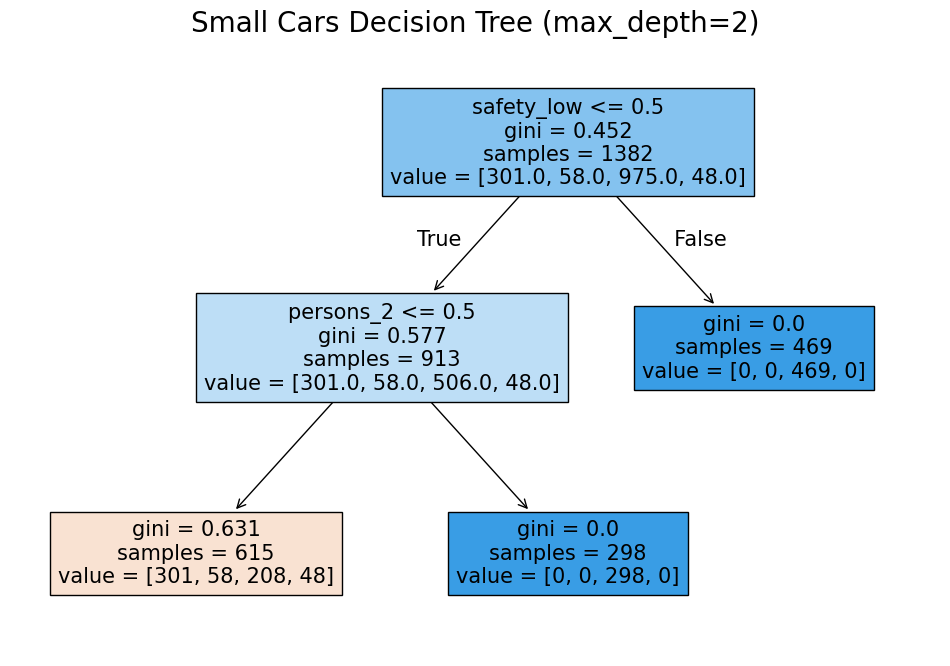


Printing Feature Importances: 
Full Decision Trees:

Full Decision Tree Voting Feature Importances:


,Feature,Importance
0,handicapped-infants_b'n',0.000000
1,handicapped-infants_b'y',0.000000
2,handicapped-infants_Unknown,0.000000
3,water-project-cost-sharing_b'n',0.000000
4,water-project-cost-sharing_b'y',0.000000
5,water-project-cost-sharing_Unknown,0.000000
6,adoption-of-the-budget-resolution_b'n',0.000000
7,adoption-of-the-budget-resolution_b'y',0.000000
8,adoption-of-the-budget-resolution_Unknown,0.000000
9,physician-fee-freeze_b'n',0.000000



 Full Decision Tree Car Feature Importances:


,Feature,Importance
0,buying_high,0.000000
1,buying_low,0.000000
2,buying_med,0.000000
3,buying_vhigh,0.000000
4,maint_high,0.000000
5,maint_low,0.000000
6,maint_med,0.000000
7,maint_vhigh,0.000000
8,doors_2,0.000000
9,doors_3,0.000000


Small Decision Trees:

Small Decision Voting Feature Importances:


...

,Feature,Importance
0,buying_high,0.000000
1,buying_low,0.000000
2,buying_med,0.000000
3,buying_vhigh,0.000000
4,maint_high,0.000000
5,maint_low,0.000000
6,maint_med,0.000000
7,maint_vhigh,0.000000
8,doors_2,0.000000
9,doors_3,0.000000



Voting Feature Importances:


,Feature,Importance
0,handicapped-infants_b'n',0.000000
1,handicapped-infants_b'y',0.000000
2,handicapped-infants_Unknown,0.000000
3,water-project-cost-sharing_b'n',0.000000
4,water-project-cost-sharing_b'y',0.000000
5,water-project-cost-sharing_Unknown,0.000000
6,adoption-of-the-budget-resolution_b'n',0.000000
7,adoption-of-the-budget-resolution_b'y',0.000000
8,adoption-of-the-budget-resolution_Unknown,0.000000
9,physician-fee-freeze_b'n',0.000000



Car Feature Importances:


,Feature,Importance
0,buying_high,0.000000
1,buying_low,0.000000
2,buying_med,0.000000
3,buying_vhigh,0.000000
4,maint_high,0.000000
5,maint_low,0.000000
6,maint_med,0.000000
7,maint_vhigh,0.000000
8,doors_2,0.000000
9,doors_3,0.000000


In [7]:
#Print induced trees for the voting and car data sets
from sklearn import tree

# Re-fit classifiers with a max depth
    #Voting
X = voting_na_df.drop(["Class"], axis = 1)
y = voting_na_df["Class"]
X = X.fillna("Unknown")
X = pd.get_dummies(X)

voting_attributes = X.columns

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42)

small_dtc_voting = DecisionTreeClassifier(max_depth = 2)
small_dtc_voting.fit(X_train, np.ravel(y_train))

    #Cars
X = cars_df.drop(["class"], axis = 1)
y = cars_df["class"]
X = pd.get_dummies(X)

cars_attributes = X.columns

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42)

small_dtc_cars = DecisionTreeClassifier(max_depth = 2)
small_dtc_cars.fit(X_train, np.ravel(y_train))

print("Printing full trees for \"voting.arff\" and \"cars.arff\":")

plt.figure(figsize = (24,16))
tree.plot_tree(dtc_voting, feature_names = voting_attributes, filled = True)
plt.title("Full Voting Decision Tree", fontsize=20)
plt.show()

plt.figure(figsize = (24,16))
tree.plot_tree(dtc_cars, feature_names = cars_attributes, filled = True)
plt.title("Full Cars Decision Tree", fontsize=20)
plt.show()

#Print the small Decision Trees
print("Printing small (max_depth = 2) trees for \"voting.arff\" and \"cars.arff\":")

plt.figure(figsize = (12,8))
tree.plot_tree(small_dtc_voting, feature_names = voting_attributes, filled = True)
plt.title("Small Voting Decision Tree (max_depth=2)", fontsize=20)
plt.show()

plt.figure(figsize = (12,8))
tree.plot_tree(small_dtc_cars, feature_names = cars_attributes, filled = True)
plt.title("Small Cars Decision Tree (max_depth=2)", fontsize=20)
plt.show()

# Feature Importances:

print("\nPrinting Feature Importances: ")
print("Full Decision Trees:")

print("\nFull Decision Tree Voting Feature Importances:")
voting_importance_df = pd.DataFrame({
    "Feature": voting_attributes,
    "Importance": small_dtc_voting.feature_importances_
})
display(voting_importance_df)

print("\n Full Decision Tree Car Feature Importances:")
cars_importance_df = pd.DataFrame({
    "Feature": cars_attributes,
    "Importance": small_dtc_cars.feature_importances_
})
display(cars_importance_df)

print("Small Decision Trees:")

print("\nSmall Decision Voting Feature Importances:")
voting_importance_df = pd.DataFrame({
    "Feature": voting_attributes,
    "Importance": small_dtc_voting.feature_importances_
})
display(voting_importance_df)

print("\nSmall Decision Tree Car Feature Importances:")
cars_importance_df = pd.DataFrame({
    "Feature": cars_attributes,
    "Importance": small_dtc_cars.feature_importances_
})
display(cars_importance_df)

print("\nVoting Feature Importances:")
voting_importance_df = pd.DataFrame({
    "Feature": voting_attributes,
    "Importance": small_dtc_voting.feature_importances_
})
display(voting_importance_df)

print("\nCar Feature Importances:")
cars_importance_df = pd.DataFrame({
    "Feature": cars_attributes,
    "Importance": small_dtc_cars.feature_importances_
})
display(cars_importance_df)


#### Discussion 
Discuss what the Trees have learned on the 2 data sets (i.e. look at the induced trees and describe what "rules" they discovered). How do the important features you would think about correspond the the "feature_importances_"

The initial trees that were shown are large and incredibly hard to look at / trace. For both of them, the words inside the nodes can't even be read! I'm guessing that this amount of depth really isn't needed to make an accurate enough decision tree and that a lot of these decisions are just noise. 

In the smaller trees, it is easier to see the decisions that are being made and narrow it down. So I am going to use the smaller trees in my analysis of what the trees learned and the features that I would think would be important in the splitting. 

Looking at only the attributes of the voting data set, I would definitely guess that the physician-fee-freeze (free healthcare?) and immigration would be features that were likely to be split on just juding by the poitical climate of our country right now. The small decision tree for the voting data set "learned" the rule of splitting first by physician-fee-freeze, and then if true, by unknown immigration status, and then if false, splitting by synfuels-corporation-cutback. If synfuel-corporation-cutback relates to gas prices I could see how that would be one of the splits that was deemed important. Compared to what I thought, I would say the tree resembles this and the feature_importances_ relay this same kind of information: physician-fee-freeze has an importance proportion of 0.9525 which is INCREDIBLY high, meaning that it is very important. This suprised me how high it is. The other two features that were split on have < 0.1 importance! Crazy!

Looking at only the attributes of the cars data set, I would guess that safety was the primary measure of the "acceptability of a car" just because that is very generally important to people. The small decision tree for the cars data set "learned" the rule of splitting first by low safety (possibly suggesting that there was no difference between high and medium safety?), and then if true, by people, and then if false, saying the car was acceptable.Compared to what I thought, I would say the tree resembles the importance of saftey and the feature_importances_ relay this same kind of information: safety_low has an importance proportion of 0.41 which is decently high. What suprised me, though, is that persons had a higher importance proportion but it was not split on first! I wonder why that is.

I printing both of the feature importances just to see if they changed between the large and small trees, it was interesting to see that they did not change. 

### 2.4 (5%) Other Parameters
- For either of the data sets above experiment and discuss using a different split criterion (Compare Entropy and Log-loss with Gini)

Decision Trees For Each Criterion:


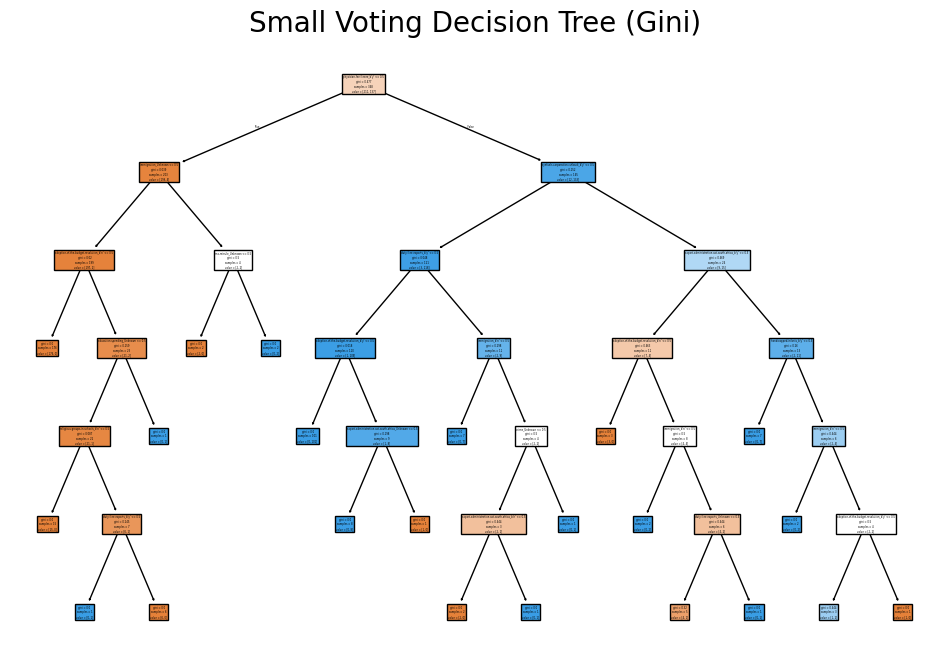

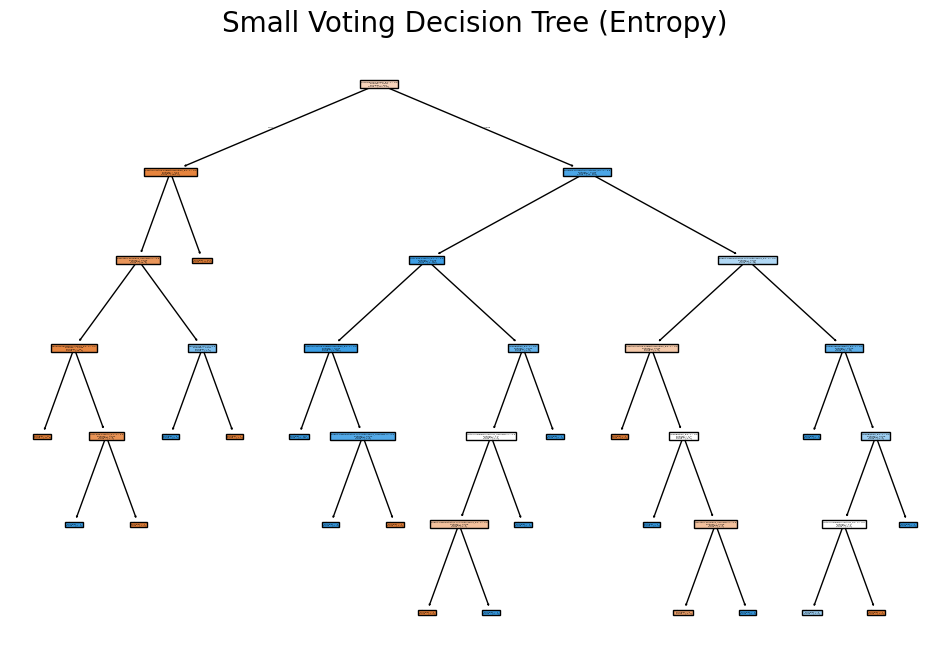

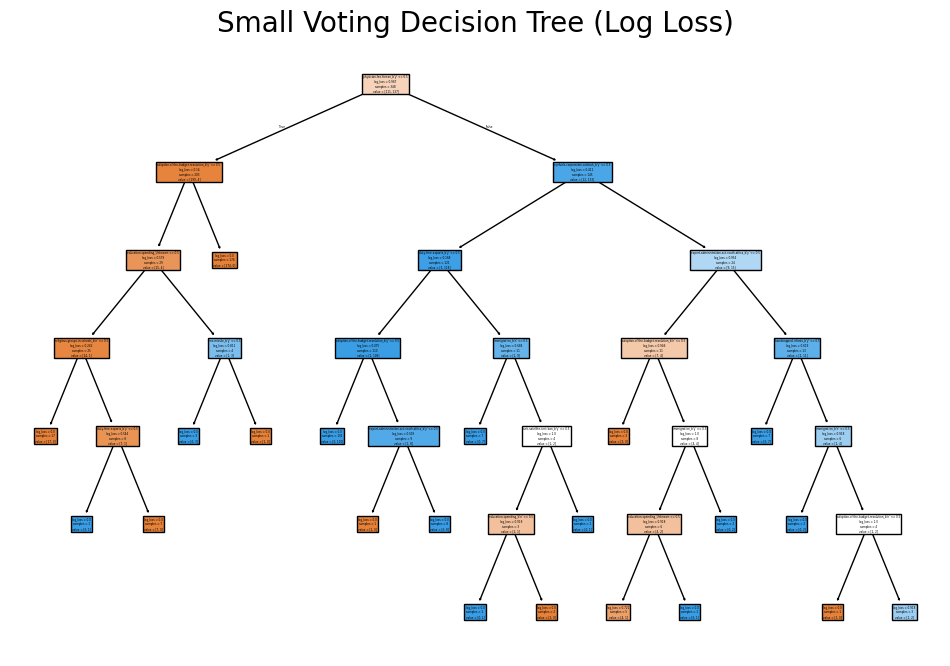


Train and Test Accuracies for Each Criterion:


,Train Accuracy,Test Accuracy
Criterion,,
Gini,0.994253,0.942529
Entropy,0.994253,0.942529
Log-loss,0.994253,0.942529


Feature Importances for Each Criterion:


,Gini Importance,Entropy Importance,Log-loss Importance
handicapped-infants_b'n',0.000000,0.000000,0.000000
handicapped-infants_b'y',0.004399,0.007699,0.007699
handicapped-infants_Unknown,0.000000,0.000000,0.000000
water-project-cost-sharing_b'n',0.000000,0.000000,0.000000
water-project-cost-sharing_b'y',0.000000,0.000000,0.000000
water-project-cost-sharing_Unknown,0.000000,0.000000,0.000000
adoption-of-the-budget-resolution_b'n',0.008570,0.007275,0.011046
adoption-of-the-budget-resolution_b'y',0.005335,0.046269,0.046269
adoption-of-the-budget-resolution_Unknown,0.000000,0.000000,0.000000
physician-fee-freeze_b'n',0.000000,0.000000,0.000000


In [8]:
# Experiment with criterion parameter for voting data set 
X = voting_na_df.drop(["Class"], axis = 1)
y = voting_na_df["Class"]
X = X.fillna("Unknown")
X = pd.get_dummies(X)

voting_attributes = X.columns

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42)

classifier_names = ["Gini", "Entropy", "Log-loss"]

print("Decision Trees For Each Criterion:")
# Gini
gini_dtc = DecisionTreeClassifier(max_depth = 6)
gini_dtc.fit(X_train, np.ravel(y_train))

plt.figure(figsize = (12,8))
tree.plot_tree(gini_dtc, feature_names = voting_attributes, filled = True)
plt.title("Small Voting Decision Tree (Gini)", fontsize=20)
plt.show()

# Entropy
entropy_dtc = DecisionTreeClassifier(criterion = "entropy", max_depth = 6)
entropy_dtc.fit(X_train, np.ravel(y_train))

plt.figure(figsize = (12,8))
tree.plot_tree(entropy_dtc, feature_names = voting_attributes, filled = True)
plt.title("Small Voting Decision Tree (Entropy)", fontsize=20)
plt.show()

# Log-loss
logloss_dtc = DecisionTreeClassifier(criterion = "log_loss", max_depth = 6)
logloss_dtc.fit(X_train, np.ravel(y_train))

plt.figure(figsize = (12,8))
tree.plot_tree(logloss_dtc, feature_names = voting_attributes, filled = True)
plt.title("Small Voting Decision Tree (Log Loss)", fontsize=20)
plt.show()

#########################################################################

classifiers = [gini_dtc, entropy_dtc, logloss_dtc]

# Create dataframes of accuracies and feature importances!
clfs = zip(classifier_names, classifiers)
accs = []
feat_importances = {}

for name, classifier in clfs:
    # Predictions 
    train_pred = classifier.predict(X_train)
    test_pred = classifier.predict(X_test)
    
    # Accuracies
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    
    # Feature importances
    feature_importances = classifier.feature_importances_
    
    accs.append({
        "Criterion": name,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
    })

    feat_importances[f"{name} Importance"] = classifier.feature_importances_

acc_df = pd.DataFrame(accs)
acc_df.set_index("Criterion", inplace = True)

feat_importances = pd.DataFrame(feat_importances, index=X_train.columns)

print("\nTrain and Test Accuracies for Each Criterion:")
display(acc_df)

print("Feature Importances for Each Criterion:")
display(feat_importances)

#### Discussion
How does using different split criteria (entropy, log-loss, and gini) affect accuracy, tree structure, and feature importance?

Interestingly enough, and probably not a great example of this because the tree that is being used above is so shallow (max_depth = 2), the test and train accuracies of the trees above, even with different criterion were identical! I tried a couple different values and as max_depth was increased, there were some splits where there were different values and one of the criterion would stand out as a slightly better metric. This taught me both about how a different criterion can affect the resulting splits, but also how having incredbly shallow trees can sometimes hide differences in models that would be starkly different if the trees were a little deeper. 

That being said, even when accuracy was similar or identical, there were train/test splits that the actual decision splits were different from tree to tree - where the root node would be same but one or both of the nodes under would be different. Also, in nearly every split, the importance features were different from one another, sometimes just by a little and sometimes as much as 0.2 or more! There were even times where two criterion would have 0.0 for the importance and the other criterion would have 0.13 or something! 

I'm guessing that in real-world data sets (and much deeper trees!) using a different criterion does not drastically change the accuracy of a tree, but can have huge effects on tree structure and feature importance, like I saw here.

## 3 Overfit Avoidance with Decision Trees  

Above, you found typical training and test set scores for the Cars data set when the tree is induced as far as it can go (until classes are pure or there are no more data or attributes to split on).  This usually leads to great training set scores but can potentially overfit and get lower accuracy on the test set.  You will now experiment with methods which can help avoid overfit and which could lead to better test set accuracy (though training set accuracy may decrease).  

### 3.1 Smaller and Simpler Trees (20%) 
- tree_: [Read about](https://scikit-learn.org/stable/auto_examples/tree/plot_unveil_tree_structure.html#sphx-glr-auto-examples-tree-plot-unveil-tree-structure-py) the tree_ attribute with its sub attributes and methods allowing you to interact with your learned tree.  You don't have to do any specific task for this part.
- Use an 80/20 train/test split for all experiments in this part and induce (learn/fit) the full tree for Cars.
- For the fully induced tree print out
    - Training set accuracy
    - Test set accuracy
    - Total number of nodes (clf.tree_.node_count)
    - Maximum tree depth (clf.tree_.max_depth)
- Experiment with the following parameters which lead to smaller and/or simpler trees which can help with overfit.  Try a few different values of each parameter and compare their train and test set accuracies and number of nodes and depth with the fully induced tree.  If you are not sure how parameters are actually working, print some trees to see their effect.  Due to the simplicity of the Cars data set you may not see as great of accuracy improvements as you would for cases where overfit is more prominent.  
    - min_samples_leaf
    - min_samples_split
    - min_impurity_decrease
- Try these parameters also, but note that they could lead to underfit
    - max_depth
    - max_leaf_nodes
    - max_features

EDA: 
	First 5 rows of cars data set:


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc



Car Type Distributions: 


class
acc       384
good       69
unacc    1210
vgood      65
Name: count, dtype: int64

Data shape:      buying  maint  doors persons lug_boot safety  class
0     vhigh  vhigh      2       2    small    low  unacc
1     vhigh  vhigh      2       2    small    med  unacc
2     vhigh  vhigh      2       2    small   high  unacc
3     vhigh  vhigh      2       2      med    low  unacc
4     vhigh  vhigh      2       2      med    med  unacc
...     ...    ...    ...     ...      ...    ...    ...
1723    low    low  5more    more      med    med   good
1724    low    low  5more    more      med   high  vgood
1725    low    low  5more    more      big    low  unacc
1726    low    low  5more    more      big    med   good
1727    low    low  5more    more      big   high  vgood

[1728 rows x 7 columns]


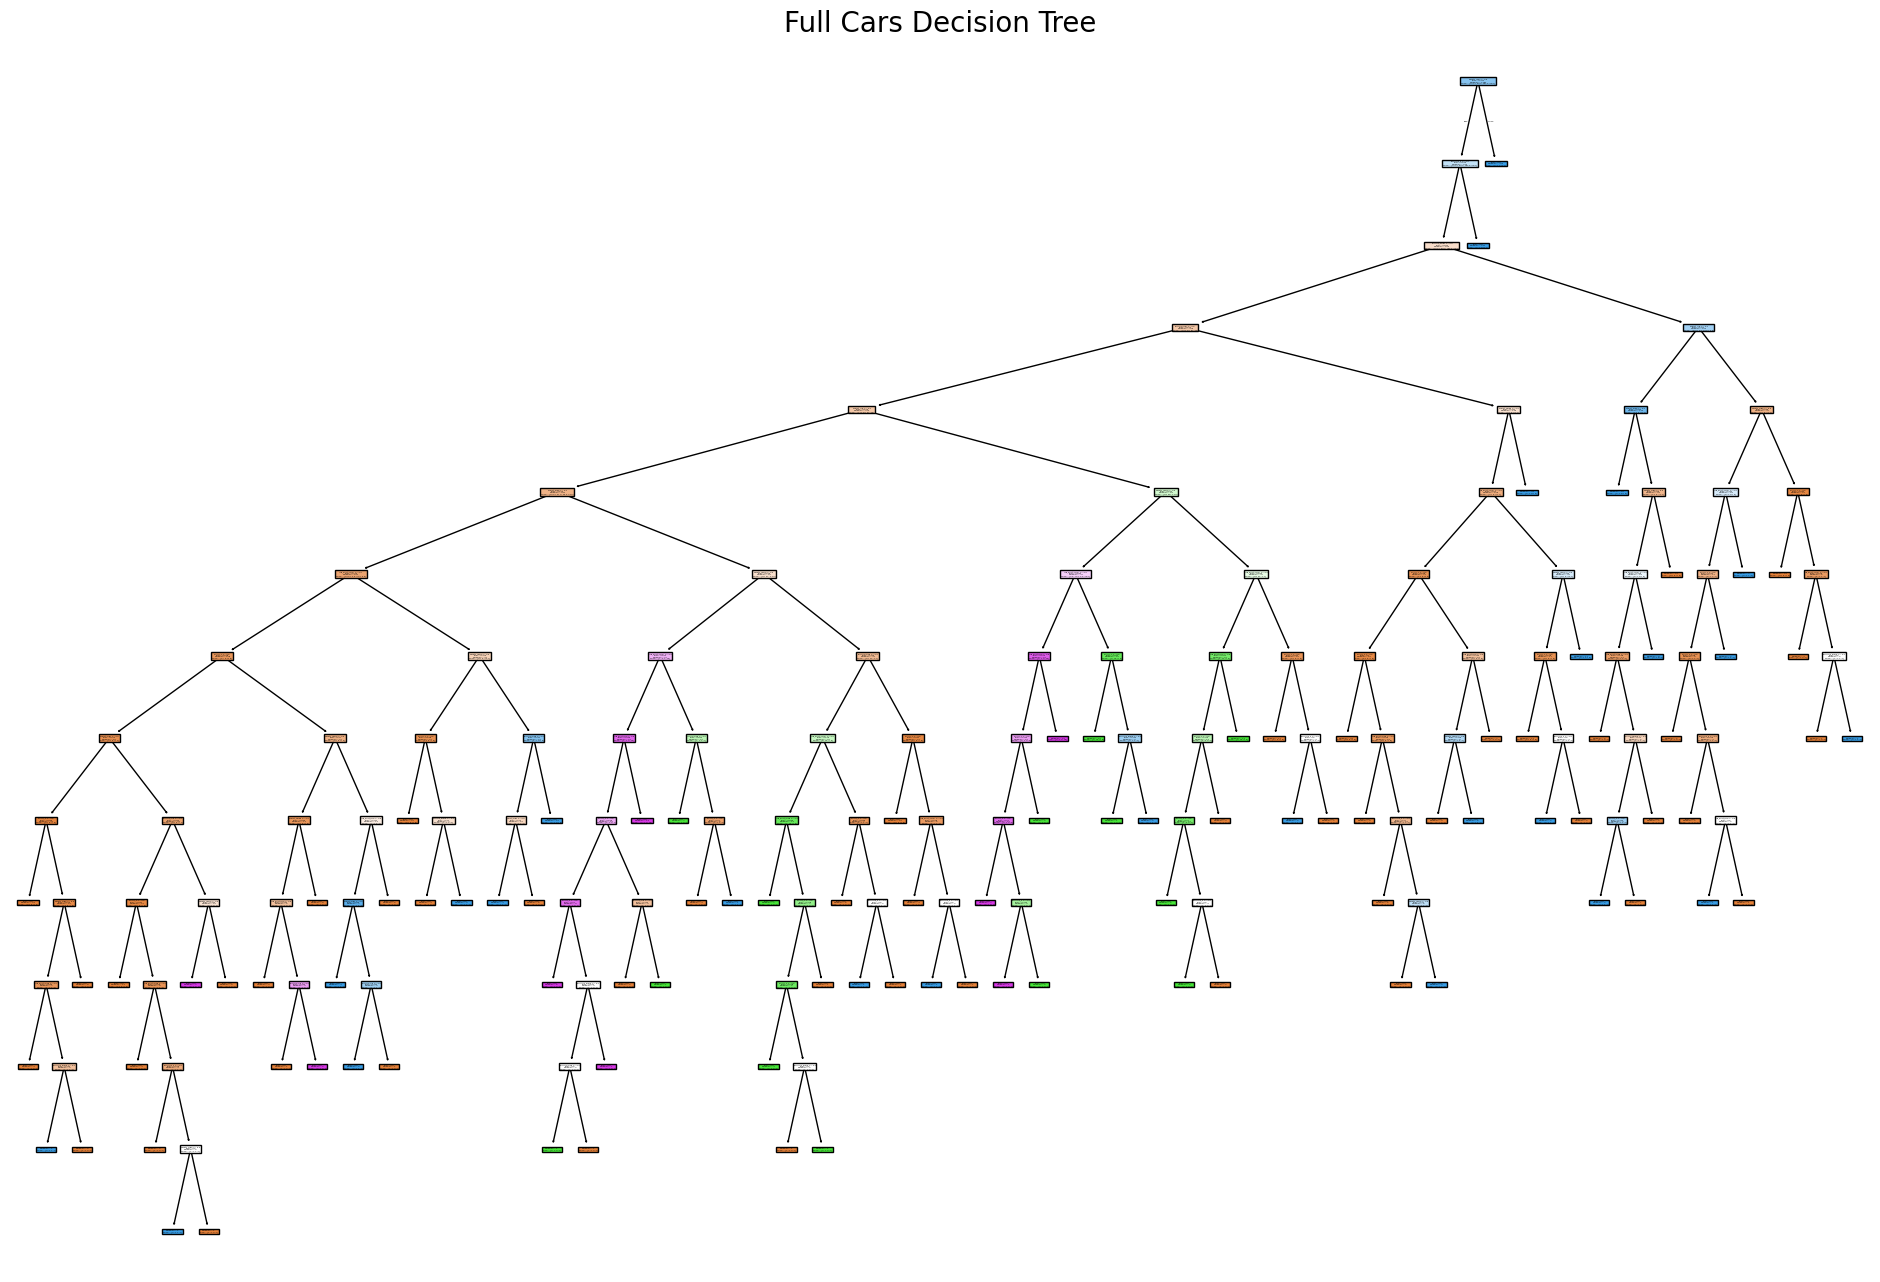

,Full Tree Value
Metric,
Train Accuracy,1.000000
Test Accuracy,0.954023


Total Number of Nodes: 191
Maximum Tree Depth: 14

Accuracy Values of a Decision Tree With Changed min_samples_leaf Compared to the Full Tree:


,Full Value,min_samples_leaf = 1,min_samples_leaf = 3,min_samples_leaf = 5,min_samples_leaf = 7
Metric,,,,,
Train Accuracy,1.000000,1.000000,0.979740,0.965268,0.958032
Test Accuracy,0.976879,0.976879,0.956647,0.930636,0.933526



Accuracy Values of a Decision Tree With Changed min_samples_split Compared to the Full Tree:


,Full Value,min_samples_split = 2,min_samples_split = 4,min_samples_split = 6,min_samples_split = 8
Metric,,,,,
Train Accuracy,1.000000,1.000000,0.989146,0.981910,0.978292
Test Accuracy,0.976879,0.973988,0.953757,0.953757,0.950867


...

,Full Value,max_depth = 1,max_depth = 3,max_depth = 5,max_depth = 7
Metric,,,,,
Train Accuracy,1.000000,0.697540,0.813314,0.876266,0.931983
Test Accuracy,0.976879,0.710983,0.774566,0.869942,0.913295



Accuracy Values of a Decision Tree With Changed max_leaf_nodes Compared to the Full Tree:


,Full Value,max_leaf_nodes = 2,max_leaf_nodes = 4,max_leaf_nodes = 6,max_leaf_nodes = 8
Metric,,,,,
Train Accuracy,1.000000,0.697540,0.813314,0.837192,0.864689
Test Accuracy,0.976879,0.710983,0.774566,0.817919,0.852601



Accuracy Values of a Decision Tree With Changed max_features Compared to the Full Tree:


,Full Value,max_features = 1,max_features = 3,max_features = 5,max_features = 7
Metric,,,,,
Train Accuracy,1.000000,1.000000,1.000000,1.000000,1.000000
Test Accuracy,0.976879,0.768786,0.875723,0.904624,0.950867


In [9]:
# Explore different overfit parameters

# The Same Quick EDA - because I like to have it!
print("EDA: ")
print("\tFirst 5 rows of cars data set:")
display(cars_df.head())

print("\nCar Type Distributions: ")
display(cars_df["class"].value_counts().sort_index())

print(f"Data shape: {cars_df}")

# Create X and y frames
X = cars_df.drop(["class"], axis = 1)
y = cars_df["class"]

X = pd.get_dummies(X)

# Do a 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 11
)

# Initiate and Fit Classifier, full tree, default parameters
dtc_cars = DecisionTreeClassifier()
dtc_cars.fit(X_train, np.ravel(y_train))

# Display the Full tree
cars_attributes = X.columns
plt.figure(figsize = (24,16))
tree.plot_tree(dtc_cars, feature_names = cars_attributes, filled = True)
plt.title("Full Cars Decision Tree", fontsize=20)
plt.show()

# Predictions and Accuracy Scores For Full Tree
y_train_pred = dtc_cars.predict(X_train)
y_test_pred = dtc_cars.predict(X_test)

full_train_accuracy = accuracy_score(y_train, y_train_pred)
full_test_accuracy = accuracy_score(y_test, y_test_pred)

accuracies = {"Metric": ["Train Accuracy", "Test Accuracy"], "Full Tree Value": [train_accuracy, test_accuracy]}
accuracies = pd.DataFrame(accuracies)
accuracies.set_index("Metric", inplace = True)
display(accuracies)

#Total nodes and max tree depth
print(f"Total Number of Nodes: {dtc_cars.tree_.node_count}")
print(f"Maximum Tree Depth: {dtc_cars.tree_.max_depth}")

#Function to compare the values with different values
def train_test_accuracies(classifiers, param):
    """Given a list of classifiers, fit the classifier, and train and test values, return a data frame comparing the newly
    calculated accuracy values compared to the accuracy values from the full tree."""

    accuracies = {"Metric": ["Train Accuracy", "Test Accuracy"], "Full Value": [full_train_accuracy, full_test_accuracy]}

    for classifier, param_value in classifiers:
        classifier.fit(X_train, y_train)

        y_train_pred = classifier.predict(X_train)
        y_test_pred = classifier.predict(X_test)

        train_accuracy = accuracy_score(y_train, y_train_pred)
        test_accuracy = accuracy_score(y_test, y_test_pred)

        accuracies[f"{param} = {param_value}"] = [train_accuracy, test_accuracy]

    accuracies = pd.DataFrame(accuracies)
    accuracies.set_index("Metric", inplace = True)

    print(f"\nAccuracy Values of a Decision Tree With Changed {param} Compared to the Full Tree:")
    display(accuracies)

# Create lists of classifiers with differing values
min_samples_leaf = []
min_samples_split = []
min_impurity_decrease = []
max_depth = []
max_leaf_nodes = []
max_features = []
for i in range(1, 8, 2):
    min_samples_leaf.append((DecisionTreeClassifier(min_samples_leaf = i), i))
    min_samples_split.append((DecisionTreeClassifier(min_samples_split = i+1), i+1)) #must be an integer >= 2, so just add one to each int
    min_impurity_decrease.append((DecisionTreeClassifier(min_impurity_decrease = i/1000), i/1000)) #must be a decimal so divide by 1000
    max_depth.append((DecisionTreeClassifier(max_depth= i), i))
    max_leaf_nodes.append((DecisionTreeClassifier(max_leaf_nodes = i + 1), i + 1)) #must be an integer >=2, so just add one to each int
    max_features.append((DecisionTreeClassifier(max_features = i), i)) 

# Display all the tables!
train_test_accuracies(min_samples_leaf, "min_samples_leaf")
train_test_accuracies(min_samples_split, "min_samples_split")
train_test_accuracies(min_impurity_decrease, "min_impurity_decrease")
train_test_accuracies(max_depth, "max_depth")
train_test_accuracies(max_leaf_nodes, "max_leaf_nodes")
train_test_accuracies(max_features, "max_features")





#### Discussion
How did the methods used above help avoid overfit? How do you know? How did they affect accuracy (training and test) and tree structure? Which parameters helped the most with each dataset? How do you know?

I started by doing the same little EDA that I usually do - nothing special. And then I printed out the full tree to see the size of it as well as the train and test metrics and node counts / max tree depth for this particular full tree. The training accuracy is 1.00 and the test accuracy is about 0.976. I think this is to be expected for this kind of tree. It can perfectly learn the training data and then does an almost perfect job predicting the test data. 

I decided to get a range of values to test for each of the parameters, calculate their train and test accuracies for each of these values and compared it to the column of the original train and test accuracies so I could more easily see how things were changing.

This is how each of the parameters were adjusting the accuracy values:

min_samples_leaf - values 1-7
min_samples_leaf changes the number of samples that are required in order to make a new leaf. By increasing this value, leafs are required to be based upon more information and thus prevents overfitting and the decision tree just memorizing the data. It will make the structure of the tree smaller and less complex, making a smoother decision boundary. This is seen here, with min_samples_leaf = 1, the train and test accuracy are identical to the full tree (because this is the default value). As this parameter value increases, the train and test accuracies both decrease ever so slightly, indicating that it is still accurate but is not too overfitted to the training data set. In fact, with a value of 7, the test accuracy was actually higher than with a value of 5. 

min_samples_split - values 2-8
min_samples_split works in a kind of similar way where there has to be a minimum number of instances in order for a split to occur, and if the number of instances is less than this value, it will automatically become a leaf. By increasing this value, more information is required to do a split, reducing the number of tiny, inconsequential splits that lead to the tree memorizing the data.  It will make the structure of the tree smaller and less complex, making a smoother decision boundary.Similarly here to the previous parameter, we see that with the default value of 2, it is the same as the full tree, and as the value increases, the test and train accuracies slightly decrease, never getting below 0.95 for either of them, indicating that the tree is still extremely good at predicting the output classification. 

min_impurity_decrease - values 0.001-0.003
min_impurity_decrease works by making sure that each split reduces the impurity by at least that much. I chose small values,because they have a large effect on splits, I probably could have chosen even smaller ones. But I saw pretty dramatic decreases in accuracy, the most so far, with 0.007 as the parameter having only a 0.89 test accuracy. It definitely reduces overfitting, but as this value gets larger, it looks like it starts to underfit!

max_depth - values 1-7
max_depth sets how deep the tree can be. This can SEVERELY change the structure and accuracy of a tree, there is a certain number of nodes that a tree needs to have in order to accurately predict, so setting this variable manually can lead to severe underfitting. With a max_depth of 1, it only has a 0.71 test accuracy (and an even lower train accuracy) which shows that the model is very underfitted! As the param values allow for a deeper tree, the accuracy increases, with a max_depth of 7 with an accuracy back up to 0.91. To reduce overfitting, changing one of the three above parameters would probably be better and run less risk of underfitting.

max_leaf_nodes - values 2-8:
max_leaf_nodes limits the number of terminal nodes that a tree can have. And similar to max_depth, makes it incredibly likely that the model is underfitted and not a good tool for predicting output class. This limits the number of decision regions that can exist, no matter how large or complex the data set is. Here, with a value of 2, the test and train accuracies are both about 0.70, and increase as more terminal nodes are allowed, all the way up to 8, but that still only has an accuracy (both train and test) of about 0.85. 

max_features - values 1-7
max_features will randomly select the number of features from the tree to base the split on, rather than using all of them in the full decision tree. Here, we see that the train accuracy is 1.000 for every feature but the test accuracy is variable, this is because there is no depth or leaf limit set, so even though it is looking at a different number of features each time, it can keep splitting until the training data is memorized. While the test accuracy is highly dependent on the split of the data. 


Parameters that helped the most with overfitting are the first three. They are ones that did not set a hard limit on the depth, but has some kind of metric that the tree can use to make its splits / decisions. It can go as deep as it needs to... so long as there is enough information to make the split! This means that every decision that is made will have more basis based on the training data, and, in theory, will be able to be better generalized to other data and be a better predictive model. 

### 3.2 (10%) Tree Reduction
Another approach to avoiding overfit is using pruning to reduce fully induced trees.  Induce the tree fully for Cars (no simplifying parameters such as max_depth).  Prune by setting the [ccp_alpha](https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html#sphx-glr-auto-examples-tree-plot-cost-complexity-pruning-py) parameter to a positive value. This parameter controls how aggressive the pruning is. Try some small values (e.g. ,001, ,005, etc.) and try to find and report the value which works the best.  Make a table with at least 5 ccp_alpha values and for each value include
- Training set accuracy (you chooses the size of the train/test split)
- Test set accuracy
- Total number of nodes (clf.tree_.node_count)
- Maximum tree depth (clf.tree_.max_depth)

In [ ]:
# Pruning
# Create X and y frames
X = cars_df.drop(["class"], axis = 1)
y = cars_df["class"]

X = pd.get_dummies(X)

# Do a 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 11
)

# Generate ccp_alpha parameter values
ccp_alphas = [0, 0.001] + [i/1000 for i in range(5, 30, 5)]
print(ccp_alphas)

df = {"Metric": ["Train Accuracy", "Test Accuracy"]}
df2 = {"Tree Details" : ["Nodes", "Depth"]}

# Initiate and Fit Classifiers, add values to dictionary
for alpha in ccp_alphas:
    dtc_cars = DecisionTreeClassifier(ccp_alpha = alpha)
    dtc_cars.fit(X_train, np.ravel(y_train))

    y_train_pred = dtc_cars.predict(X_train)
    y_test_pred = dtc_cars.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    nodes = dtc_cars.tree_.node_count
    depth = dtc_cars.tree_.max_depth

    df[f"cpp_alpha = {alpha}"] = [train_acc, test_acc]
    df2[f"cpp_alpha = {alpha}"] = [nodes, depth]

df = pd.DataFrame(df)
df.set_index("Metric", inplace = True)
df2 = pd.DataFrame(df2)
df2.set_index("Tree Details", inplace = True)

print("\nTrain and Test Accuracies:")
display(df)
print("\nTree Nodes and Depth: ")
display(df2)


[0, 0.001, 0.005, 0.01, 0.015, 0.02, 0.025]

Train and Test Accuracies:


,cpp_alpha = 0,cpp_alpha = 0.001,cpp_alpha = 0.005,cpp_alpha = 0.01,cpp_alpha = 0.015,cpp_alpha = 0.02,cpp_alpha = 0.025
Metric,,,,,,,
Train Accuracy,1.000000,0.986975,0.934877,0.874819,0.851664,0.813314,0.778582
Test Accuracy,0.973988,0.959538,0.936416,0.881503,0.835260,0.774566,0.774566



Tree Nodes and Depth: 


,cpp_alpha = 0,cpp_alpha = 0.001,cpp_alpha = 0.005,cpp_alpha = 0.01,cpp_alpha = 0.015,cpp_alpha = 0.02,cpp_alpha = 0.025
Tree Details,,,,,,,
Nodes,191,117,39,17,13,7,5
Depth,14,11,8,5,5,3,2


#### Discussion
How did the pruning parameter ccp_alpha affect accuracy and tree structure? How does that compare to the methods above?

The pruning parameter ccp_alpha works by allowing the full tree to be constructed, and then going back through the nodes of the tree to calculate how much the given node actually improves the overall impurity. Alpha is the value that the node must improve the score in order to justify keeping it. The methods above do not allow for the full tree to be constructued before determining what nodes can stay in the tree, and rather make decisions as the tree is being constructed (pre-pruning) to whether a leaf is worth having / keeping. Though these methods will lead to faster training, they can discard splits that would lead to later very advantageous and useful splits, making decision trees even more greedy. Using ccp_alpha (post_pruning) may take longer, but can be advantageous because it allows all splits to be explored beforegoing and removing weak branches. When alpha values are small / optimized, they reduce complexity (size) of the decision tree and often can improve or have no effect on the test accuracy, saving computation. If the value of alpha is too large / not optimized, it can over simplify the tree and cause test accuracy 

I chose to look at 7 different alpha values (0 (default), 0.001, 0005, 0.010, 0.015, 0.020, and 0.025) to see how they affect training and testing accuracies as well as number of nodes and depth of the tree. The origina tree has 191 nodes and a depth of 14 with a 1.0 training accuracy and a 0.97 test accuracy. I made sure to include this in my report so that I had a baseline to compare it to. From there, there is an easily observable pattern, the training and testing accuracies slowly decrease as ccp_alpha is increases, and the tree complexity (both nodes and overall tree depth) decrease as well. This is to be expected as increases ccp_alpha increases the amount of pruning that is done. 

Some interesting things that I observed:
    Between the ccp_alpha values of 0.02 and 0.025 (which I think are very high for this data set seeing as how it reduces the nodes and depth to < 10 for both of them) the testing accuracy is the exact same! I would guess that if this occurred in a situation where the tree wasn't so heavily pruned, that would be a good instance to use the higher ccp_alpha value. Similarly, though not a change of 0, for ccp_alpha values of 0.001 and 0.005, there is only a 0.02 drop in testing accuracy, which I would assume is almost negligible for most models in terms of prediction accuracy, but the tree complexity VASTLY decreses, going from 117 nodes and a depth of 11 to only 39 nodes and a depth of 8. I would guess that this would be one of the instances where sacrificing that 0.02 test accuracy would be well worth the drop in complexity and the saving of computational power. This was a great show of how tuning hyperparameters is effective at minimizing model complexity while conserving prediction accuracies. 

## 4. Decision Tree Regression
### 4.1 (15%) Learn a real-world regression data set of your choice (not already used in this or previous labs)
- Report tree statistics (# of nodes, # of leaf nodes, max depth)
- Report MAE on the training and test set (you choose the size of the train/test split)
- Report the DT regressor score for the training and test set.  Note that for the DT regressor this score is the coefficient of determination. Google it if you are curious.

In [52]:
#Learn regression data set
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Read the CSV file into a data frame
car_price_df = pd.read_csv("data/car_price.csv")

# Quick EDA
print("EDA:")
print("\tFirst 5 rows of car price data set: ")
display(car_price_df.head())

# Remove the missing rows
car_price_df = car_price_df.dropna(how="all")

# Get X and y, drop Car ID
X = car_price_df.drop(["Price", "Car ID"], axis = 1)
y = car_price_df["Price"]

# One-hot Encode Categorical columns of X
categorical_cols = X.select_dtypes(include = ["object"]).columns
X = pd.get_dummies(X, columns = categorical_cols)

# Train and Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 3
)

# Initialize and Fit the Regression (with default params)
dtr = DecisionTreeRegressor(min_samples_leaf = 75, random_state = 3)
dtr.fit(X_train, np.ravel(y_train))

# Tree Statistics
total_nodes = dtr.tree_.node_count
leaf_nodes = dtr.get_n_leaves()
max_depth = dtr.tree_.max_depth

print(f"Total Nodes: {total_nodes}")
print(f"Leaf Nodes: {leaf_nodes}")
print(f"Max Tree Depth: {max_depth}")

# Prediction
y_pred = dtr.predict(X_test)

# MAE
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae}")

# Coef. of Determination
r2 = r2_score(y_test, y_pred)
print(f"Coefficient of Determination: {r2}")


EDA:
	First 5 rows of car price data set: 


,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1.0,Tesla,2016.0,2.3,Petrol,Manual,114832.0,New,26613.92,Model X
1,2.0,BMW,2018.0,4.4,Electric,Manual,143190.0,Used,14679.61,5 Series
2,3.0,Audi,2013.0,4.5,Electric,Manual,181601.0,New,44402.61,A4
3,4.0,Tesla,2011.0,4.1,Diesel,Automatic,68682.0,New,86374.33,Model Y
4,5.0,Ford,2009.0,2.6,Diesel,Manual,223009.0,Like New,73577.10,Mustang


Total Nodes: 33
Leaf Nodes: 17
Max Tree Depth: 6
Mean Absolute Error: 24208.487879932214
Coefficient of Determination: -0.059544643755594207


C:\Users\User\AppData\Local\Temp\ipykernel_19244\1021137337.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include = ["object"]).columns


#### Discussion
Discuss your choice of dataset and regression feature. Also discuss the items listed above in 4.1

So, I found a dataset on Kaggle that is a car data set that has some features like model, year, trasmission, mileage, fuel type, etc., that I could do this regression on. I chose it because I could get some practice handling missing values (this one has entire missing rows that I dropped) and with one-hot encoding since there was a combination of nominal and continuous values. I also chose it because we could predict on price (which is the chosen regression feature), which is a continuous feature and what regressors are aiming to be able to predict. As far as I can tell, data sets like this are super common candidates for doing regressions on. 

The issue is, this data set has some old cars that are like $20,000 all the way up to modern, luxury sports cars that are 1/4 million dollars. So there is a absolutely HUGE range of values that are going on in the price situation. Initially when I did the regressor with default values, there were 3599 nodes and 1800 leaf nodes. Which is kind of insane... a super complex tree! The even crazier part is that the MAE was like $32,600 (because of how wide the range of price values are) and the R2 score was -1.1 - which literally means that the model does a worse job predicting prices than it would do if it just guessed the same value (the mean) every time. Which is like, horrible. It is an awful model for predicting car prices based on this data... and not even because the tree is over simplified or anything, it is like SO complex and still sucks at prediction. 

Obviously the point of this part of this assignment is not to make an insanely optimized model or anything, but I did poke around a little just to see if I could make it even a little bit better. I played around with ccp_alpha values a little, and hoenstly they did nothing. Less than nothing, they actually I think made the model worse. So I moved to playing around with min_samples_leaf and min_samples_split, to try and see if I could reduce the MAE and get my R2 score at least to 0. Min_samples_split honestly didn't do much of anything either, so I just focused on min_samples_leaf right now and started at 5, I incremented by ones for a minute before realizing that incrementing by 5 would be a better idea. With a min_samples_leaf of 75, yes seventy-five, the MAE was reduced to around 24200, and the r2 score is just under 0, like -0.05. Which is still performing worse than the baseline, but at least its not THAT much worse, and now there are only 33 total nodes and a max depth of 6. So the tree is at least cheap and bad instead of computationally expensive and still bad, haha. Overall, I'm sure there are other things that could be done to get better numbers and predictions but wow is this model bad. 



## 5. (Optional 15% extra credit) Code up your own C4.5 Decision Tree Learner 
Implement the C4.5 algorithm discussed in class and in the slides, NOT the CART algorithm.  Below is a scaffold you could use if you want. Requirements for this task:
- Your model should support the methods shown in the example scaffold below.
- Use standard information gain as your basic attribute evaluation metric.  Note that C4.5 would usually augment information gain with a mechanism to penalize statistically insignificant attribute splits to avoid overfit (e.g. early stopping, gain ratio, etc.), but you are not required to do that.
- Include the ability to handle unknown attributes by making "unknown" a new attribute value when needed.
- You do not need to handle real valued attributes.
- It is a good idea to use simple data set (like the pizza homework), which you can check by hand, to test each detailed step of your algorithm to make sure it works correctly. 
- Run your algorithm on the voting data set above with unknown attributes and compare your results with CART.

DISCUSSION FOR THE EXTRA CREDIT PORTION:

This took me a lonnnnggggg time to do, but it was incredibly rewarding and helped me understand how Decision Trees even work, I will spare you my usual long explanation about how everything works (hopefully it is documented well enough), but essentially, I'm just building a recursive tree based on what split has the best gain ratio... which is what I am fairly sure that the C4.5 algorithm uses.

Below, you can see how it works on the tiny data set! It has a 100% accuracy for the testing class... which is not suprising since it only has to get two right haha. BUT - the magic happened when I compared it to the one that done by Sklearn... they had the exact same train and test accuracies. YAY! I'm sure that this is just largely because of the particular split and there would be differences if a different split was used... buuuut I am happy with it!

Additionally, the first version I coded used information gain, and then I looked it up and it said CART used information gain, not C4.5. Which... was a set back, not going to lie, but was just one more thing that helped me understand what was going on behind the scenes here!

In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn import datasets

class Node: # A node class to help with the tree construction
    def __init__(self, feature = None, children = None, *, value=None, majority = None):
        self.feature = feature
        self.children = children if children is not None else {}
        self.value = value
        self.majority = majority # majority class 
    
    def is_leaf_node(self):
        return self.value is not None

class DTClassifier(BaseEstimator,ClassifierMixin):

    def __init__(self):
        """ Initialize class with chosen hyperparameters.
        Args:
        Optional Args (Args we think will make your life easier):
            counts: A list of Ints that tell you how many types of each feature there are
        Example:
            DT  = DTClassifier()
            or
            DT = DTClassifier(count = [2,3,2,2])
            Dataset = 
            [[0,1,0,0],
            [1,2,1,1],
            [0,1,1,0],
            [1,2,0,1],
            [0,0,1,1]]

        """
        self.root = None # Tree starts empty when initialized, duh!
    
    def majority_label(self, y):
        """A helper function to find the majoriy label."""
        # Create a counts dictionary, find how many times each label occurs
        counts = {}
        for label in y: # Typically counting for loop yay
            if label in counts:
                counts[label] += 1
            else:
                counts[label] = 1
        
        # Find label with max count from dictionary
        max_count = -1
        majority_label = None
        for label, count in counts.items(): # Not sure how to do this more efficiently... they should let you sort a dictionary by values :(
            if count > max_count:
                max_count = count
                majority_label = label
        return majority_label
    
    def entropy(self, y):
        """A helper function that Calculates entropy for the y values."""
        _, counts = np.unique(y, return_counts = True) #we don't need values here, so stored in an underscore
        p_values = counts / len(y)

        entropy = 0
        for p in p_values:
            if p > 0:
                entropy -= p * np.log2(p) # where entropy is the negative sum of the probability times the log base 2 of the probability 
        
        return entropy


    def gain_ratio(self, X_column, y):
        """Calculate gain ratio for a given split."""
        # Parent Entropy
        parent_entropy = self.entropy(y) #using the entropy function thatt was written 

        values, counts = np.unique(X_column, return_counts = True) #get unique values (and counts of each!)

        split_info = 0
        weighted_entropy = 0

        for value, count in zip(values, counts): #iterate through all possible splits
            small_y = y[X_column == value] # get the number of y's that equal our value
            probability = count / len(y) # calculate the probability

            weighted_entropy += probability * self.entropy(small_y) #calculate weighted entropy, expected entropy if the info was split by this feature

            if probability > 0:
                split_info -= probability * np.log2(probability) #features with more unique values have lower gain ratios... (they provide less info!)
        
        info_gain = parent_entropy - weighted_entropy #just normal information gain

        if split_info == 0: 
            return 0
        
        return info_gain / split_info #gain ratio is the information gain divided by the split information

    def find_best_feature(self, X, y):
        """Given the X and y, calculate the best feature to split on based on the gain ratio."""
        best_gain = -1
        best_feature = None

        for feature_idx in range(X.shape[1]):
            X_column = X[:, feature_idx]
            gain = self.gain_ratio(X_column, y) #calculate the gain ratio for each

            if gain > best_gain: #check if it is better than the best
                best_gain = gain
                best_feature = feature_idx
        
        return best_feature, best_gain # return the best ones!

    def grow_tree(self, X, y, depth = 0):
        """A helper function that grows the tree according to what feature will result in the best split,
        creates nodes, returns resulting Node from calculations."""
        majority = self.majority_label(y) #calculate the majority from what is in y

        if len(np.unique(y)) == 1: #If there is only one more feature in y, return a node with the remaining feature as the value
            return Node(value=y[0], majority = majority)

        if X.shape[1] == 0: 
            return Node(value = majority, majority = majority)

        best_feature, best_gain = self.find_best_feature(X, y)

        if best_gain == 0:
            return Node(value = majority, majority = majority)

        children = {} #child dictionary, since C4.5 doesn't only do binary splits and can split on numerous features 
        feature_values = np.unique(X[:, best_feature])

        for value in feature_values:
            idxs = np.where(X[:, best_feature] == value)[0]

            child_X = np.delete(X[idxs], best_feature, axis=1)
            child_y = y[idxs]

            children[value] = self.grow_tree(child_X, child_y, depth+1)

        return Node(feature = best_feature, children = children, majority = majority)


    def fit(self, X, y):
        """ Fit the data; Make the Decision tree
        Args:
            X (array-like): A 2D numpy array with the training data, excluding targets
            y (array-like): A 1D numpy array with the training targets
        Returns:
            self: this allows this to be chained, e.g. model.fit(X,y).predict(X_test)
        """
        # Replace unknown values :)
        X = np.array(X, dtype=object)
        y = np.array(y) #change from a pandas series to a numpy array
        
        X[X == None] = "Unknown" # Handle/change common unknown values if not already done
        X[X == "?"] = "Unknown" 

        self.root = self.grow_tree(X, y) # grow the tree, starting from the root 
        return self

    def traverse_tree(self, X, node):
        if node.is_leaf_node():
            return node.value

        feature_value = X[node.feature]

        if feature_value in node.children:
            # delete the feature for the child (since we can't split on the same feature twice), but keep x as 1D array
            new_x = np.delete(X, node.feature)
            return self.traverse_tree(new_x, node.children[feature_value])
        else:
            return node.majority # If there is no info, or an unknown feature, just return the majority class by default (as stored in node)

    def predict(self, X):
        X = np.array(X)  # ensure numpy
        # make sure X is 2D
        if X.ndim == 1:
            X = X.reshape(1, -1)
        predictions = np.array([self.traverse_tree(x, self.root) for x in X]) #for every value in x, traverse! output the final class predictions!
        return predictions

    def score(self, X, y):
        """ Return accuracy(Classification Acc) of model on a given dataset. Must implement own score function.

        Args:
            X (array-like): A 2D numpy array with data, excluding targets
            y (array-like): A 1D numpy array of the targets 
        """
        predictions = self.predict(X)
        y = np.array(y)  #change from a pandas series to a numpy array
        return np.mean(predictions == y)

In [80]:
# Optional Debugging Dataset - Pizza Homework
pizza_dataset = np.array([[1,2,0],[0,0,0],[0,1,1],[1,1,1],[1,0,0],[1,0,1],[0,2,1],[1,0,0],[0,2,0]])
pizza_labels = np.array([2,0,1,2,1,2,1,1,0])

X = pizza_dataset
y = pizza_labels

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2)

my_clf = DTClassifier()
my_clf.fit(X_train, y_train)

print("Mini pizza dataset (to show that it is kind of working at least):")

y_pred = my_clf.predict(X_test)
print("\n\tWhat my Decision Tree Classifer predicts:")
print(f"\t{y_pred}")

score = my_clf.score(X_test, y_test)
print("\n\tThe Accuracy of my Decision Tree Classifier:")
print(f"\t{score}")

########################################################################
print("\n\nLarger Voting Dataset:")

# Get X and y
X = voting_na_df.drop(["Class"], axis = 1)
y = voting_na_df["Class"]

# One-hot encoding for nominal features:
X = pd.get_dummies(X)

# Do a split!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 123
)

# Dictionary for clean output
accuracies = {"Metric:" : ["Train Accuracy", "Test Accuracy"]}

# For each classifer, initialize, fit, predict, get accuracies
my_clf = DTClassifier()
my_clf.fit(X_train, np.ravel(y_train))
train_accuracy = my_clf.score(X_train, y_train)
test_accuracy = my_clf.score(X_test, np.ravel(y_test))
accuracies["My DTC"] = [train_accuracy, test_accuracy]

clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)
train_accuracy = clf.score(X_train, y_train)
test_accuracy = clf.score(X_test, y_test)
accuracies["SKLearn's DTC"] = [train_accuracy, test_accuracy]

accuracies = pd.DataFrame(accuracies)
display(accuracies)

Mini pizza dataset (to show that it is kind of working at least):

	What my Decision Tree Classifer predicts:
	[1 0]

	The Accuracy of my Decision Tree Classifier:
	1.0


Larger Voting Dataset:


,Metric:,My DTC,SKLearn's DTC
0,Train Accuracy,1.000000,1.000000
1,Test Accuracy,0.908046,0.908046
